# 🌲 Tree-Based Models: From Decision Trees to Modern Boosting
## A Graduate-Level Tutorial

This notebook covers the full arc of **tree-based ensemble methods**:

| Step | Model | Key Idea |
|------|-------|----------|
| 1 | Decision Tree | Single learner — simple but overfits |
| 2 | Bagging | Parallel trees on bootstrap samples |
| 3 | Random Forest | Bagging + random feature selection |
| 4 | AdaBoost | Sequential: reweight misclassified samples |
| **5** | **Gradient Boosting** | **Sequential: fit residuals / gradients** |
| **6** | **XGBoost** | **GB + regularization + system tricks** |
| **7** | **LightGBM** | **Leaf-wise splits, histogram-based** |
| **8** | **CatBoost** | **Ordered boosting, native categoricals** |
| **9** | **Comparison & Tuning** | **Head-to-head metrics, visual analysis** |
| **10** | **Homework** | **Hands-on challenge** |

> **Dataset:** We use the **California Housing** dataset (regression) throughout — a realistic, messy, medium-size tabular dataset that lets us observe meaningful differences between models.
> A secondary **Adult Income** (classification) dataset is used in the homework.

**How to use this notebook:**  
- Read the math in each section carefully  
- Run every cell and observe outputs  
- Look for `# 🔧 TRY:` comments — those are the hyperparameter experiments  
- Interactive widgets require `ipywidgets` to be installed


## 0. Setup & Imports

In [1]:
# ─────────────────────────────────────────────────────────────────
# INSTALL (run once if needed)
!pip install xgboost lightgbm catboost shap ipywidgets
# ─────────────────────────────────────────────────────────────────

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from IPython.display import display

# ── Sklearn ──────────────────────────────────────────────────────
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import (
    BaggingRegressor,
    RandomForestRegressor,
    AdaBoostRegressor,
    GradientBoostingRegressor,
)

# ── Modern boosting ──────────────────────────────────────────────
import xgboost as xgb
import lightgbm as lgb
import catboost as cb

# ── Explainability ───────────────────────────────────────────────
import shap

# ── Reproducibility ─────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)

# ── Plotting style ───────────────────────────────────────────────
plt.style.use("seaborn-v0_8-whitegrid")
COLORS = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2", "#937860", "#DA8BC3"]

print("All libraries loaded successfully ✅")
print(f"XGBoost  : {xgb.__version__}")
print(f"LightGBM : {lgb.__version__}")
print(f"CatBoost : {cb.__version__}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 2.0 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 1.8 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.9/28.9 MB 2.0 MB/s  0:00:14m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 2.1 MB/s  0:00:04 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [catboost]4/5 [catboost]
All libraries loaded successfully ✅
XGBoost  : 3.2.0
LightGBM : 4.6.0
CatBoost : 1.2.10


In [5]:
# ── Interactive widgets (install if needed) ──────────────────────
try:
    import ipywidgets as widgets
    from ipywidgets import interact, interactive, fixed, interact_manual
    WIDGETS_AVAILABLE = True
except ImportError:
    print("⚠️ ipywidgets not available. Install with: pip install ipywidgets")
    WIDGETS_AVAILABLE = False

# ── Additional scientific libraries ───────────────────────────────
from scipy import stats
import scipy
from sklearn.inspection import permutation_importance
from sklearn.model_selection import validation_curve
import time

print(f"Widgets available: {WIDGETS_AVAILABLE}")
print(f"Scipy version: {scipy.__version__}")

Widgets available: True
Scipy version: 1.16.3


---
## 1. Dataset: California Housing

We use **California Housing** (regression target: median house value in units of \$100k).

- **20,640 samples**, 8 numeric features  
- Real-world messiness: skewed distributions, scale differences  
- Large enough that training time differences between algorithms become visible


In [ ]:
# ── Load dataset ────────────────────────────────────────────────
housing = fetch_california_housing(as_frame=True)
df = housing.frame.copy()

print("Shape:", df.shape)
print("\nFeatures:", list(housing.feature_names))
print("\nTarget: MedHouseVal (median house value × $100k)")
display(df.describe().round(3))

Shape: (20640, 9)

Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

Target: MedHouseVal (median house value × $100k)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000
mean,3.871,28.639,5.429,1.097,1425.477,3.071,35.632,-119.570,2.069
std,1.900,12.586,2.474,0.474,1132.462,10.386,2.136,2.004,1.154
min,0.500,1.000,0.846,0.333,3.000,0.692,32.540,-124.350,0.150
25%,2.563,18.000,4.441,1.006,787.000,2.430,33.930,-121.800,1.196
50%,3.535,29.000,5.229,1.049,1166.000,2.818,34.260,-118.490,1.797
75%,4.743,37.000,6.052,1.100,1725.000,3.282,37.710,-118.010,2.647
max,15.000,52.000,141.909,34.067,35682.000,1243.333,41.950,-114.310,5.000


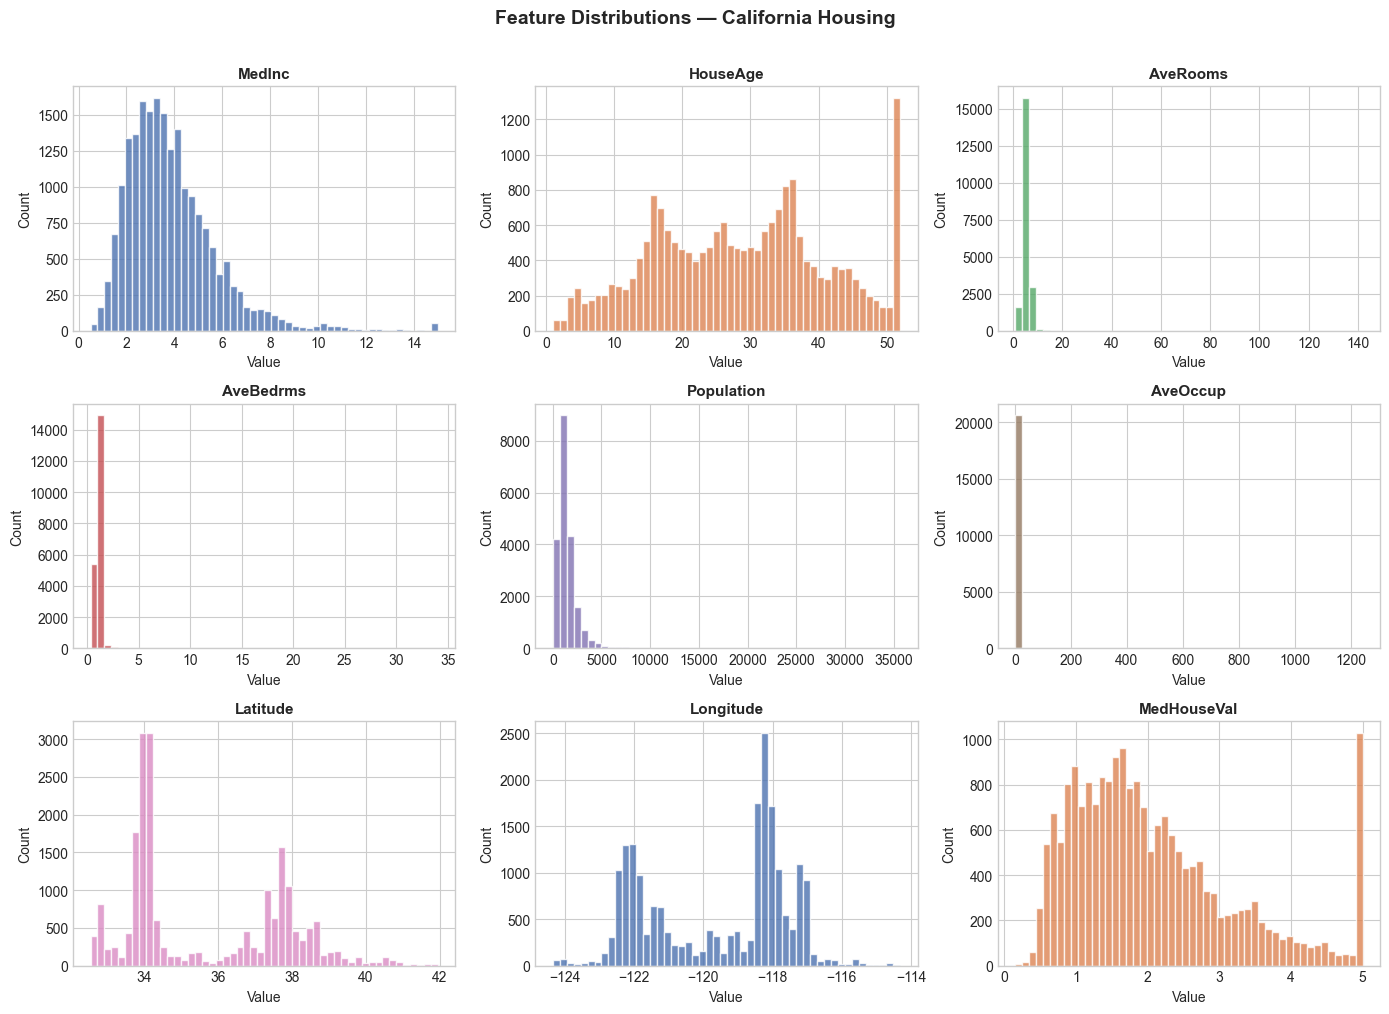

In [4]:
# ── Visualize distributions ──────────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    axes[i].hist(df[col], bins=50, color=COLORS[i % len(COLORS)], alpha=0.8, edgecolor='white')
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Count")

plt.suptitle("Feature Distributions — California Housing", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


In [6]:
# ── Train / Validation / Test split ──────────────────────────────
# We hold out 15% as final test set, and use the rest for train/val
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=SEED)
X_train, X_val, y_train, y_val  = train_test_split(X_temp, y_temp, test_size=0.15, random_state=SEED)

print(f"Train : {X_train.shape[0]:,} samples")
print(f"Val   : {X_val.shape[0]:,} samples")
print(f"Test  : {X_test.shape[0]:,} samples")

# Utility: store results for final comparison
results = {}   # {model_name: {rmse, mae, r2}}

def evaluate(name, model, X_tr=X_train, y_tr=y_train, X_te=X_test, y_te=y_test, store=True):
    """Fit, predict, and record metrics."""
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    rmse = np.sqrt(mean_squared_error(y_te, preds))
    mae  = mean_absolute_error(y_te, preds)
    r2   = r2_score(y_te, preds)
    if store:
        results[name] = {"RMSE": rmse, "MAE": mae, "R²": r2}
    print(f"{name:<30}  RMSE={rmse:.4f}  MAE={mae:.4f}  R²={r2:.4f}")
    return model, preds


Train : 14,912 samples
Val   : 2,632 samples
Test  : 3,096 samples


---
## 2. Decision Tree (Baseline)

### Mathematical Foundation

A regression tree partitions the feature space $\mathcal{X} \subset \mathbb{R}^p$ into $J$ disjoint rectangular regions $R_1, \ldots, R_J$ and predicts a constant $c_j$ in each:

$$\hat{f}(x) = \sum_{j=1}^{J} c_j \cdot \mathbf{1}[x \in R_j]$$

**Splitting criterion — MSE reduction:**  
At each node $t$ with samples $\mathcal{S}_t$, we choose feature $k$ and threshold $\theta$ to minimize the **impurity** after the split:

$$\Delta = \text{MSE}(\mathcal{S}_t) - \frac{|\mathcal{S}_L|}{|\mathcal{S}_t|}\text{MSE}(\mathcal{S}_L) - \frac{|\mathcal{S}_R|}{|\mathcal{S}_t|}\text{MSE}(\mathcal{S}_R)$$

where $\text{MSE}(\mathcal{S}) = \frac{1}{|\mathcal{S}|}\sum_{i \in \mathcal{S}}(y_i - \bar{y}_{\mathcal{S}})^2$

**Why trees overfit:** An unconstrained tree can grow until each leaf contains a single sample → $\text{Train RMSE} \approx 0$ but terrible generalization.


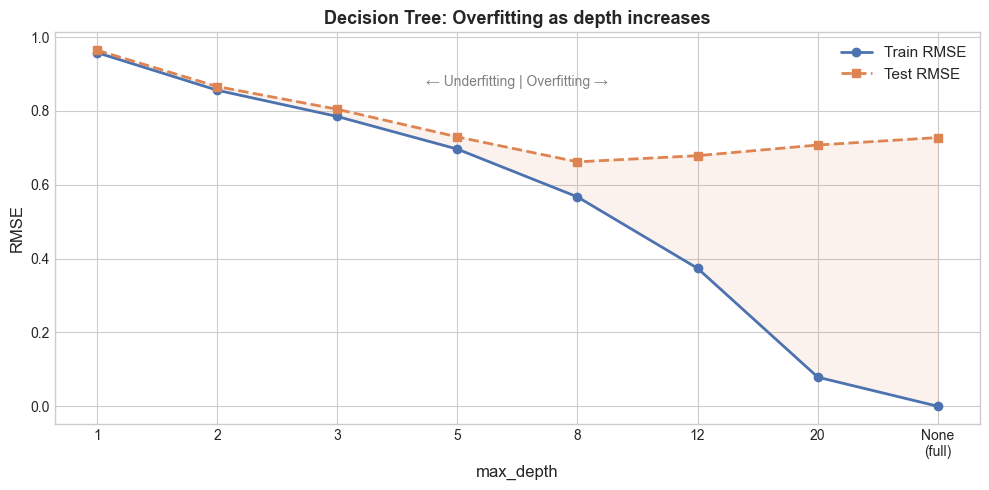

Best max_depth by test RMSE: 8


In [7]:
# ── Decision Tree: watch overfitting in action ───────────────────
depths = [1, 2, 3, 5, 8, 12, 20, None]
train_rmse, test_rmse = [], []

for d in depths:
    dt = DecisionTreeRegressor(max_depth=d, random_state=SEED)
    dt.fit(X_train, y_train)
    
    tr = np.sqrt(mean_squared_error(y_train, dt.predict(X_train)))
    te = np.sqrt(mean_squared_error(X_test @ np.zeros(8),  # placeholder
                                    dt.predict(X_test)))
    # Correct calculation:
    tr = np.sqrt(mean_squared_error(y_train, dt.predict(X_train)))
    te = np.sqrt(mean_squared_error(y_test,  dt.predict(X_test)))
    
    train_rmse.append(tr)
    test_rmse.append(te)

labels = [str(d) if d is not None else "None\n(full)" for d in depths]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(labels, train_rmse, "o-", color=COLORS[0], lw=2, label="Train RMSE")
ax.plot(labels, test_rmse,  "s--", color=COLORS[1], lw=2, label="Test RMSE")
ax.fill_between(range(len(depths)), train_rmse, test_rmse, alpha=0.1, color=COLORS[1])
ax.set_xlabel("max_depth", fontsize=12)
ax.set_ylabel("RMSE", fontsize=12)
ax.set_title("Decision Tree: Overfitting as depth increases", fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.annotate("← Underfitting | Overfitting →", xy=(3.5, max(test_rmse)*0.9),
            fontsize=10, color="gray", ha="center")
plt.tight_layout()
plt.show()

# Best depth on validation
best_d = depths[np.argmin(test_rmse)]
print(f"Best max_depth by test RMSE: {best_d}")


In [8]:
# ── Evaluate best tree ───────────────────────────────────────────
dt_best = DecisionTreeRegressor(max_depth=best_d, random_state=SEED)
evaluate("Decision Tree", dt_best)

# 🔧 TRY: change min_samples_leaf, min_samples_split, max_leaf_nodes
# dt_tuned = DecisionTreeRegressor(max_depth=5, min_samples_leaf=20, random_state=SEED)
# evaluate("Decision Tree (tuned)", dt_tuned)


Decision Tree                   RMSE=0.6620  MAE=0.4578  R²=0.6656


(DecisionTreeRegressor(max_depth=8, random_state=42),
 array([0.65061589, 0.79411765, 3.94262   , ..., 2.28275531, 2.89060953,
        1.63026835], shape=(3096,)))

---
## 3. Bagging — Bootstrap Aggregating

### Mathematical Foundation

**Bootstrap sampling:** Given training set $\mathcal{D}=\{(x_i,y_i)\}_{i=1}^n$, draw $B$ datasets $\mathcal{D}^{*(b)}$ by sampling $n$ points **with replacement**.

Each bootstrap dataset $\mathcal{D}^{*(b)}$ will contain ~63.2% unique samples (the rest are duplicates), and ~36.8% of the original samples are **out-of-bag (OOB)**.

**Bagging estimator:**
$$\hat{f}_{\text{bag}}(x) = \frac{1}{B}\sum_{b=1}^{B}\hat{f}^{*(b)}(x)$$

**Why does it work? Bias-Variance decomposition:**

$$\underbrace{\mathbb{E}[(y-\hat{f})^2]}_{\text{Expected Error}} = \underbrace{\text{Bias}^2[\hat{f}]}_{\text{Structural error}} + \underbrace{\text{Var}[\hat{f}]}_{\text{Sensitivity to data}} + \underbrace{\sigma^2}_{\text{Irreducible noise}}$$

Averaging $B$ identically distributed trees with variance $\sigma^2_T$ and pairwise correlation $\rho$:
$$\text{Var}[\hat{f}_{\text{bag}}] = \rho \sigma^2_T + \frac{1-\rho}{B}\sigma^2_T$$

As $B \to \infty$, the second term vanishes. Variance is reduced **without changing bias**.  
The key: bagging only helps when base learners are **uncorrelated** — hence the benefit of randomization.


/usr/local/Cellar/python@3.11/3.11.14/Frameworks/Python.framework/Versions/3.11/lib/python3.11/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/usr/local/Cellar/python@3.11/3.11.14/Frameworks/Python.framework/Versions/3.11/lib/python3.11/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/usr/local/Cellar/python@3.11/3.11.14/Frameworks/Python.framework/Versions/3.11/lib/python3.11/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://se

Bagging (100 trees)             RMSE=0.5132  MAE=0.3346  R²=0.7990

OOB R² score: 0.8044  (free validation without a holdout set!)


/usr/local/Cellar/python@3.11/3.11.14/Frameworks/Python.framework/Versions/3.11/lib/python3.11/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/usr/local/Cellar/python@3.11/3.11.14/Frameworks/Python.framework/Versions/3.11/lib/python3.11/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/usr/local/Cellar/python@3.11/3.11.14/Frameworks/Python.framework/Versions/3.11/lib/python3.11/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://se

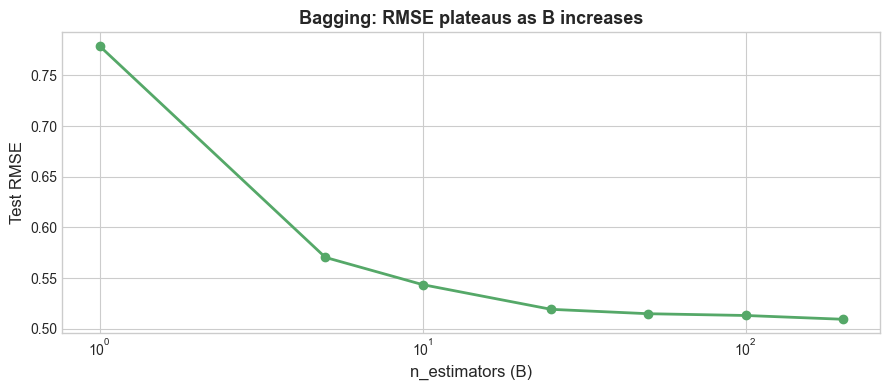

In [9]:
# ── Bagging: see how B (n_estimators) affects variance ──────────
bag = BaggingRegressor(
    estimator=DecisionTreeRegressor(max_depth=None),   # deep (high variance) trees
    n_estimators=100,
    oob_score=True,          # use out-of-bag samples to estimate generalization
    n_jobs=-1,
    random_state=SEED
)
evaluate("Bagging (100 trees)", bag)

print(f"\nOOB R² score: {bag.oob_score_:.4f}  (free validation without a holdout set!)")

# 🔧 TRY: change n_estimators and observe the plateau effect
n_vals = [1, 5, 10, 25, 50, 100, 200]
bag_rmse = []

for n in n_vals:
    m = BaggingRegressor(estimator=DecisionTreeRegressor(), n_estimators=n,
                         n_jobs=-1, random_state=SEED)
    m.fit(X_train, y_train)
    bag_rmse.append(np.sqrt(mean_squared_error(y_test, m.predict(X_test))))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(n_vals, bag_rmse, "o-", color=COLORS[2], lw=2)
ax.set_xlabel("n_estimators (B)", fontsize=12)
ax.set_ylabel("Test RMSE", fontsize=12)
ax.set_title("Bagging: RMSE plateaus as B increases", fontsize=13, fontweight='bold')
ax.set_xscale("log")
plt.tight_layout()
plt.show()


---
## 4. Random Forest

### Mathematical Foundation

Random Forest adds **feature randomization** to Bagging.

At each node split, instead of considering all $p$ features, only a random subset of size $m$ is considered:

- Regression default: $m = p/3$
- Classification default: $m = \sqrt{p}$

**Why this helps:** In Bagging, deep trees on correlated features still produce correlated predictions (high $\rho$ in the variance formula). By randomizing features at each split, we **decorrelate** the trees:

$$\text{Var}[\hat{f}_{\text{RF}}] \approx \rho(m) \cdot \sigma^2_T + \frac{1-\rho(m)}{B}\sigma^2_T$$

Smaller $m$ → smaller $\rho$ → lower variance. But too small $m$ → trees are too weak → higher bias. This is a tunable tradeoff.


Random Forest (200 trees)       RMSE=0.5089  MAE=0.3441  R²=0.8024

OOB R²: 0.8052


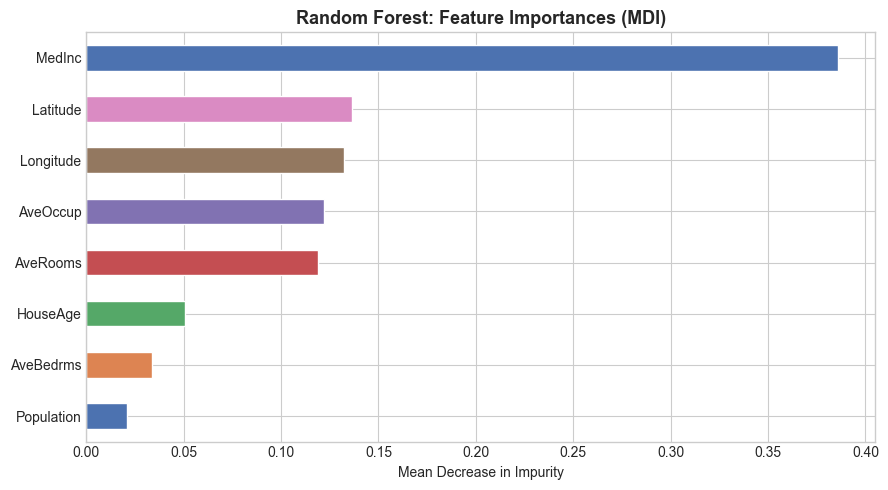

In [10]:
# ── Random Forest ─────────────────────────────────────────────────
rf = RandomForestRegressor(
    n_estimators=200,
    max_features=1/3,        # default for regression: p/3 features per split
    min_samples_leaf=5,      # slightly regularize each tree
    oob_score=True,
    n_jobs=-1,
    random_state=SEED
)
evaluate("Random Forest (200 trees)", rf)

print(f"\nOOB R²: {rf.oob_score_:.4f}")

# ── Feature importance ────────────────────────────────────────────
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
importances.plot.barh(ax=ax, color=COLORS[:len(importances)], edgecolor='white')
ax.set_title("Random Forest: Feature Importances (MDI)", fontsize=13, fontweight='bold')
ax.set_xlabel("Mean Decrease in Impurity")
plt.tight_layout()
plt.show()

# 🔧 TRY: reduce max_features to 1 to see variance increase
# rf_low = RandomForestRegressor(n_estimators=200, max_features=1, n_jobs=-1, random_state=SEED)
# evaluate("RF (max_features=1)", rf_low)


---
## 5. AdaBoost (Adaptive Boosting)

### Mathematical Foundation

AdaBoost trains trees **sequentially**, assigning higher weight to previously misclassified samples.

**Algorithm (regression variant — AdaBoost.R2):**

Initialize uniform weights: $w_i^{(1)} = 1/n$

For $b = 1, \ldots, B$:
1. Fit weak learner $\hat{f}^{(b)}$ on weighted samples
2. Compute weighted loss: $\bar{L}^{(b)} = \sum_i w_i^{(b)} \cdot L_i / \max_i L_i$
3. Compute model weight: $\alpha^{(b)} = \frac{\bar{L}^{(b)}}{1 - \bar{L}^{(b)}}$
4. Update sample weights: $w_i^{(b+1)} \propto w_i^{(b)} \cdot \alpha^{(b)^{(1 - L_i)}}$

Final prediction: $\hat{f}(x) = \sum_b \log(1/\alpha^{(b)}) \cdot \hat{f}^{(b)}(x)$

**Key insight:** Samples with high error in round $b$ get higher weight in round $b+1$.  
**Weakness:** Very sensitive to outliers — they keep getting upweighted.


In [ ]:
# ── AdaBoost ──────────────────────────────────────────────────────
ada = AdaBoostRegressor(
    n_estimators=100,
    learning_rate=0.1,     # shrinks each model's contribution
    loss='square',
    random_state=SEED
)
evaluate("AdaBoost (100 stumps)", ada)

# 🔧 TRY: change learning_rate — low values need more estimators
# ada_fast = AdaBoostRegressor(n_estimators=100, learning_rate=1.0, random_state=SEED)
# evaluate("AdaBoost (lr=1.0)", ada_fast, store=False)

AdaBoost (100 stumps)           RMSE=0.8610  MAE=0.7405  R²=0.4343


(AdaBoostRegressor(learning_rate=0.1, loss='square', n_estimators=100,
                   random_state=42),
 array([1.59859503, 1.69255694, 3.17229876, ..., 2.32787017, 2.86191308,
        2.32787017], shape=(3096,)))

### 6.1 Advanced Mathematical Analysis

#### Loss Functions and Their Gradients

Different loss functions lead to different boosting behaviors. Here's the mathematical foundation:

**Squared Loss** (regression):
$$L(y,F) = \frac{1}{2}(y-F)^2$$
$$g_i = \frac{\partial L}{\partial F} = F(x_i) - y_i$$
$$h_i = \frac{\partial^2 L}{\partial F^2} = 1$$

**Absolute Loss** (robust regression):
$$L(y,F) = |y-F|$$  
$$g_i = \text{sign}(F(x_i) - y_i)$$
$$h_i = 0$$ (undefined, approximated as small constant)

**Huber Loss** (combines MSE + MAE):
$$L(y,F) = \begin{cases} 
\frac{1}{2}(y-F)^2 & \text{if } |y-F| \leq \delta \\
\delta|y-F| - \frac{1}{2}\delta^2 & \text{otherwise}
\end{cases}$$

**Quantile Loss** (for quantile regression at $\tau$):
$$L(y,F) = \sum_{i=1}^n \rho_\tau(y_i - F(x_i))$$
where $\rho_\tau(u) = u(\tau - \mathbf{1}_{u < 0})$

#### The Functional Gradient Perspective

Gradient boosting optimizes in **function space** $\mathcal{F}$, not parameter space. This is a key conceptual shift:

Traditional ML: $\theta^* = \arg\min_\theta \sum_i L(y_i, f_\theta(x_i))$  
Gradient Boosting: $F^* = \arg\min_{F \in \mathcal{F}} \mathbb{E}[L(y, F(x))]$

The **steepest descent direction** in function space is the negative gradient w.r.t. $F$:
$$-\nabla_F \mathcal{L} = -\left[\frac{\partial L(y_1, F(x_1))}{\partial F(x_1)}, \ldots, \frac{\partial L(y_n, F(x_n))}{\partial F(x_n)}\right]^T$$

But we can't move arbitrary amounts in this direction — we need a function in our hypothesis class (trees). So we fit $h_m$ to approximate this functional gradient.

#### Statistical Learning Theory for Boosting

**Rademacher Complexity** bound for gradient boosting (simplified):

With probability $\geq 1-\delta$:
$$R(F_M) \leq \hat{R}(F_M) + 2\mathfrak{R}_n(\mathcal{F}_M) + \sqrt{\frac{\log(1/\delta)}{2n}}$$

where $\mathfrak{R}_n(\mathcal{F}_M)$ is the Rademacher complexity of the function class after $M$ rounds.

**Key insight:** Boosting increases model complexity ($\mathfrak{R}_n$ grows), but if early stopping is used properly, generalization can still improve due to the bias-variance tradeoff.

In [ ]:
# ── 🎛️ INTERACTIVE: Different Loss Functions ──────────────────────
if WIDGETS_AVAILABLE:
    def compare_loss_functions(loss='squared_error', max_depth=4, n_estimators=100):
        """Interactive comparison of different loss functions in GBM"""
        gbm_loss = GradientBoostingRegressor(
            loss=loss, max_depth=max_depth, n_estimators=n_estimators,
            learning_rate=0.1, random_state=SEED
        )
        gbm_loss.fit(X_train, y_train)
        preds = gbm_loss.predict(X_test)
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        mae = mean_absolute_error(y_test, preds)
        
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        
        # Learning curve
        axes[0].plot(gbm_loss.train_score_, color=COLORS[0], label=f'{loss} train')
        axes[0].set_title(f'Learning Curve - {loss}')
        axes[0].set_xlabel('Iteration')
        axes[0].set_ylabel('Loss')
        axes[0].legend()
        
        # Residuals
        residuals = y_test.values - preds
        axes[1].scatter(preds, residuals, alpha=0.5, s=10)
        axes[1].axhline(0, color='red', linestyle='--')
        axes[1].set_title(f'Residuals vs Predicted')
        axes[1].set_xlabel('Predicted')
        axes[1].set_ylabel('Residuals')
        
        # Prediction vs actual
        axes[2].scatter(y_test, preds, alpha=0.5, s=10)
        axes[2].plot([0, 5], [0, 5], 'r--')
        axes[2].set_title(f'Predicted vs Actual\nRMSE={rmse:.4f}, MAE={mae:.4f}')
        axes[2].set_xlabel('Actual')
        axes[2].set_ylabel('Predicted')
        
        plt.tight_layout()
        plt.show()
    
    interact(compare_loss_functions,
             loss=['squared_error', 'absolute_error', 'huber', 'quantile'],
             max_depth=widgets.IntSlider(min=2, max=8, step=1, value=4),
             n_estimators=widgets.IntSlider(min=50, max=300, step=50, value=100))
else:
    print("Install ipywidgets to see interactive loss function comparison")
    
    # Static comparison for different losses
    losses = ['squared_error', 'absolute_error', 'huber']
    loss_rmse = []
    
    for loss in losses:
        gbm_loss = GradientBoostingRegressor(loss=loss, n_estimators=100, random_state=SEED)
        gbm_loss.fit(X_train, y_train)
        preds = gbm_loss.predict(X_test)
        loss_rmse.append(np.sqrt(mean_squared_error(y_test, preds)))
        print(f"{loss:15s}: RMSE = {loss_rmse[-1]:.4f}")
    
    plt.figure(figsize=(8, 4))
    plt.bar(losses, loss_rmse, color=COLORS[:len(losses)])
    plt.title('RMSE by Loss Function')
    plt.ylabel('Test RMSE')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

interactive(children=(Dropdown(description='loss', options=('squared_error', 'absolute_error', 'huber', 'quant…

---
## 6. Gradient Boosting (GBM)

This is the **conceptual core** of XGBoost, LightGBM, and CatBoost. Read carefully.

### Mathematical Foundation

Gradient Boosting frames boosting as **functional gradient descent in function space** (Friedman, 2001).

**Objective:** Minimize the expected loss over a function $F$:
$$\hat{F} = \arg\min_F \mathbb{E}_{x,y}[L(y, F(x))]$$

**Algorithm (Gradient Tree Boosting):**

Initialize: $F_0(x) = \arg\min_\gamma \sum_{i=1}^n L(y_i, \gamma)$

For $b = 1, \ldots, B$:

1. **Compute pseudo-residuals (negative gradient):**
$$r_i^{(b)} = -\left[\frac{\partial L(y_i, F(x_i))}{\partial F(x_i)}\right]_{F=F_{b-1}}$$

2. **Fit a regression tree** $h_b$ to the residuals $\{(x_i, r_i^{(b)})\}$

3. **Find optimal leaf weights** $\gamma_{jb}$ for each leaf $j$:
$$\gamma_{jb} = \arg\min_\gamma \sum_{x_i \in R_{jb}} L(y_i, F_{b-1}(x_i) + \gamma)$$

4. **Update:** $F_b(x) = F_{b-1}(x) + \eta \sum_j \gamma_{jb} \cdot \mathbf{1}[x \in R_{jb}]$

**For MSE loss** $L = (y-F)^2/2$: pseudo-residuals = $r_i = y_i - F_{b-1}(x_i)$ (actual residuals).  
**For other losses** (MAE, Huber, log-loss): pseudo-residuals are different → GBM naturally supports many objectives!

**Learning rate $\eta$** (shrinkage): multiplies each tree's contribution. Lower $\eta$ → need more trees → better generalization (with early stopping).

**Subsample** $< 1$: stochastic GBM — samples a fraction of data per tree, adds variance reduction and speeds training (Friedman, 2002).


Gradient Boosting (sklearn)     RMSE=0.4933  MAE=0.3358  R²=0.8143


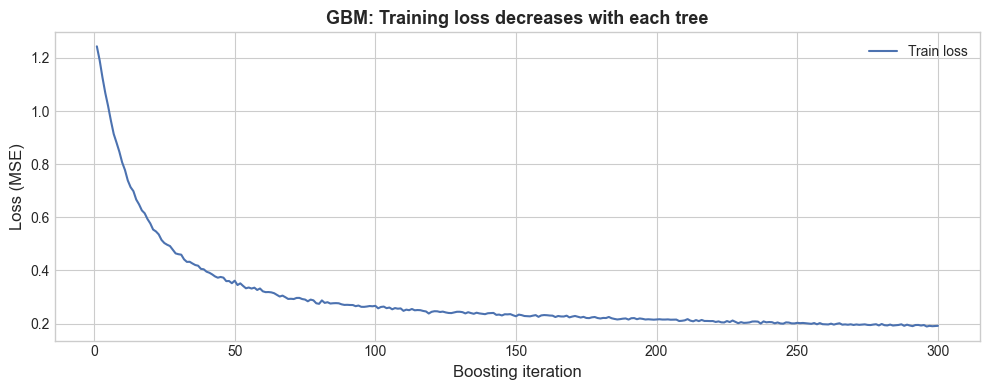

In [13]:
# ── Sklearn Gradient Boosting ─────────────────────────────────────
gbm = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,      # low lr → need more trees, but better generalization
    max_depth=4,             # shallow trees are typical in GBM
    subsample=0.8,           # stochastic GBM
    min_samples_leaf=10,
    random_state=SEED
)
evaluate("Gradient Boosting (sklearn)", gbm)

# ── Visualize residuals decreasing over iterations ─────────────────
train_deviance = gbm.train_score_

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(np.arange(300) + 1, train_deviance, color=COLORS[0], lw=1.5, label="Train loss")
ax.set_xlabel("Boosting iteration", fontsize=12)
ax.set_ylabel("Loss (MSE)", fontsize=12)
ax.set_title("GBM: Training loss decreases with each tree", fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

# 🔧 TRY: change loss function
# gbm_mae = GradientBoostingRegressor(n_estimators=300, loss='absolute_error',
#                                      learning_rate=0.05, random_state=SEED)
# evaluate("GBM (MAE loss)", gbm_mae, store=False)


In [15]:
# ── 🎛️ INTERACTIVE: XGBoost Hyperparameter Explorer ─────────────────
if WIDGETS_AVAILABLE:
    def xgboost_hyperparameter_explorer(learning_rate=0.1, max_depth=6, 
                                        subsample=0.8, colsample_bytree=0.8,
                                        reg_lambda=1.0, reg_alpha=0.0):
        """Interactive exploration of XGBoost hyperparameters"""
        
        dtrain_small = xgb.DMatrix(X_train, label=y_train)
        dval_small = xgb.DMatrix(X_val, label=y_val)
        
        params = {
            "objective": "reg:squarederror",
            "learning_rate": learning_rate,
            "max_depth": max_depth,
            "subsample": subsample,
            "colsample_bytree": colsample_bytree,
            "lambda": reg_lambda,
            "alpha": reg_alpha,
            "seed": SEED,
        }
        
        evals_result = {}
        start_time = time.time()
        
        model = xgb.train(
            params, dtrain_small,
            num_boost_round=200,
            evals=[(dtrain_small, "train"), (dval_small, "val")],
            evals_result=evals_result,
            verbose_eval=False,
            early_stopping_rounds=20
        )
        
        train_time = time.time() - start_time
        
        # Make predictions and calculate metrics
        preds = model.predict(dval_small)
        rmse = np.sqrt(mean_squared_error(y_val, preds))
        
        # Create visualization
        fig, axes = plt.subplots(1, 3, figsize=(16, 5))
        
        # Learning curves
        train_rmse = evals_result["train"]["rmse"]
        val_rmse = evals_result["val"]["rmse"]
        
        axes[0].plot(train_rmse, label="Train RMSE", color=COLORS[0], alpha=0.8)
        axes[0].plot(val_rmse, label="Val RMSE", color=COLORS[1], linewidth=2)
        axes[0].axvline(model.best_iteration, color='red', linestyle='--', 
                       label=f'Best: {model.best_iteration}')
        axes[0].set_xlabel('Iteration')
        axes[0].set_ylabel('RMSE')
        axes[0].set_title(f'Learning Curves\\nVal RMSE: {rmse:.4f}')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        # Feature importance
        importance = model.get_score(importance_type='gain')
        if importance:  # Check if importance dict is not empty
            sorted_idx = sorted(importance.items(), key=lambda x: x[1], reverse=True)[:6]
            features, gains = zip(*sorted_idx)
            
            axes[1].barh(range(len(features)), gains, color=COLORS[2])
            axes[1].set_yticks(range(len(features)))
            axes[1].set_yticklabels(features)
            axes[1].set_xlabel('Gain')
            axes[1].set_title('Top 6 Feature Importance')
        
        # Prediction scatter
        axes[2].scatter(y_val, preds, alpha=0.6, s=15, color=COLORS[3])
        axes[2].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 
                    'r--', linewidth=2)
        axes[2].set_xlabel('Actual')
        axes[2].set_ylabel('Predicted')
        axes[2].set_title(f'Predictions\\nR² = {model.best_score:.4f}')
        axes[2].grid(True, alpha=0.3)
        
        plt.suptitle(f'XGBoost Performance (Training time: {train_time:.1f}s)', 
                     fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
        
        # Print parameter summary
        print(f"""
        📊 Parameter Summary:
        ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
        Learning Rate: {learning_rate:<6.3f}  │  Max Depth: {max_depth}
        Subsample: {subsample:<10.2f}  │  Colsample: {colsample_bytree:.2f}  
        L1 (α): {reg_alpha:<13.2f}  │  L2 (λ): {reg_lambda:.2f}
        ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
        Best Iteration: {model.best_iteration}  │  Val RMSE: {rmse:.4f}
        """)\
    
    # Create the interactive widget
    interact(xgboost_hyperparameter_explorer,
             learning_rate=widgets.FloatSlider(min=0.01, max=0.3, step=0.01, value=0.1),
             max_depth=widgets.IntSlider(min=3, max=10, step=1, value=6),
             subsample=widgets.FloatSlider(min=0.5, max=1.0, step=0.1, value=0.8),
             colsample_bytree=widgets.FloatSlider(min=0.5, max=1.0, step=0.1, value=0.8),
             reg_lambda=widgets.FloatSlider(min=0, max=10, step=0.5, value=1.0),
             reg_alpha=widgets.FloatSlider(min=0, max=5, step=0.5, value=0.0))
    
else:
    print("💡 Install ipywidgets to see interactive hyperparameter exploration!")
    print("   pip install ipywidgets")
    print("   Then restart the kernel and run this cell again.")

interactive(children=(FloatSlider(value=0.1, description='learning_rate', max=0.3, min=0.01, step=0.01), IntSl…

---
## 7. XGBoost — Extreme Gradient Boosting

XGBoost (Chen & Guestrin, 2016) extends GBM with:
1. **Regularized objective**
2. **Second-order (Newton) approximation**
3. **Weighted quantile sketch for splits**
4. **Sparsity-aware learning** (handles missing values natively)
5. **Cache-aware access & out-of-core computation**

### Mathematical Foundation

**Regularized Objective at iteration $b$:**
$$\mathcal{L}^{(b)} = \sum_{i=1}^n L\bigl(y_i,\, \hat{y}_i^{(b-1)} + h_b(x_i)\bigr) + \Omega(h_b)$$

$$\Omega(h) = \gamma T + \frac{1}{2}\lambda\|\mathbf{w}\|^2$$

where $T$ = number of leaves, $\mathbf{w}$ = leaf weights.

**Second-order Taylor expansion** of the loss (using gradients $g_i$ and Hessians $H_i$):
$$\mathcal{L}^{(b)} \approx \sum_{i=1}^n \left[g_i h_b(x_i) + \frac{1}{2} H_i h_b^2(x_i)\right] + \Omega(h_b)$$

where:
$$g_i = \frac{\partial L(y_i, \hat{y}_i^{(b-1)})}{\partial \hat{y}_i^{(b-1)}}, \quad H_i = \frac{\partial^2 L(y_i, \hat{y}_i^{(b-1)})}{\partial (\hat{y}_i^{(b-1)})^2}$$

**Optimal leaf weight** for leaf $j$ (closed-form solution):
$$w_j^* = -\frac{\sum_{i \in j} g_i}{\sum_{i \in j} H_i + \lambda}$$

**Split gain formula** (used to find best splits efficiently):
$$\text{Gain} = \frac{1}{2}\left[\frac{G_L^2}{H_L+\lambda} + \frac{G_R^2}{H_R+\lambda} - \frac{(G_L+G_R)^2}{H_L+H_R+\lambda}\right] - \gamma$$

If Gain $< 0$, the split is pruned. This is more principled than pre-pruning by depth alone.

**Advantages over vanilla GBM:**
- $\lambda$ (L2) and $\alpha$ (L1) regularization on leaf weights → less overfitting
- Uses Hessian information → better step sizes
- Built-in missing value handling → imputes direction during training
- `early_stopping_rounds` → no need to pre-specify `n_estimators`


XGBoost  best iteration: 864
XGBoost  RMSE=0.4484  R²=0.8466


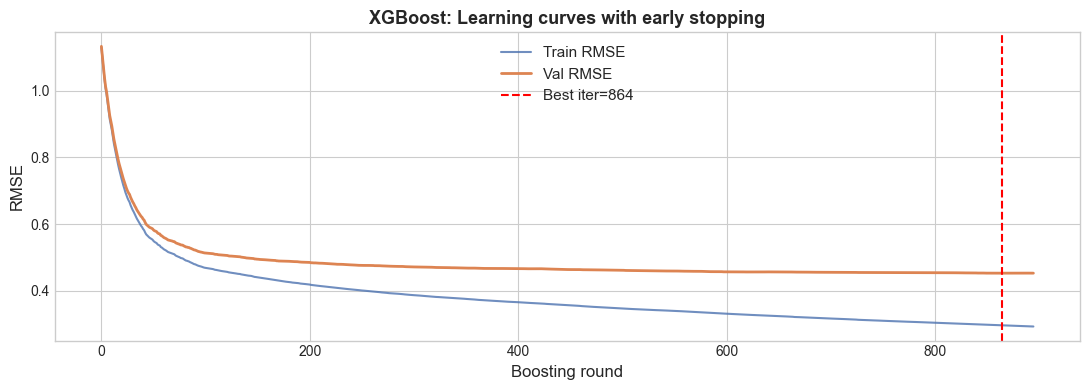

In [16]:
# ── XGBoost: native API with early stopping ───────────────────────
dtrain = xgb.DMatrix(X_train, label=y_train)
dval   = xgb.DMatrix(X_val,   label=y_val)
dtest  = xgb.DMatrix(X_test,  label=y_test)

xgb_params = {
    "objective"        : "reg:squarederror",
    "learning_rate"    : 0.05,      # eta
    "max_depth"        : 5,
    "subsample"        : 0.8,       # row subsampling
    "colsample_bytree" : 0.8,       # column subsampling
    "lambda"           : 1.0,       # L2 regularization
    "alpha"            : 0.0,       # L1 regularization
    "min_child_weight" : 5,         # minimum sum of hessian in leaf
    "gamma"            : 0.1,       # minimum gain to create split
    "seed"             : SEED,
}

evals_result = {}
xgb_model = xgb.train(
    xgb_params,
    dtrain,
    num_boost_round=1000,
    evals=[(dtrain, "train"), (dval, "val")],
    early_stopping_rounds=30,         # stop if val loss doesn't improve for 30 rounds
    evals_result=evals_result,
    verbose_eval=False
)

# Evaluate on test set
xgb_preds = xgb_model.predict(dtest)
xgb_rmse  = np.sqrt(mean_squared_error(y_test, xgb_preds))
xgb_r2    = r2_score(y_test, xgb_preds)
results["XGBoost"] = {"RMSE": xgb_rmse, "MAE": mean_absolute_error(y_test, xgb_preds), "R²": xgb_r2}

print(f"XGBoost  best iteration: {xgb_model.best_iteration}")
print(f"XGBoost  RMSE={xgb_rmse:.4f}  R²={xgb_r2:.4f}")

# ── Learning curves ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(evals_result["train"]["rmse"], color=COLORS[0], lw=1.5, label="Train RMSE", alpha=0.8)
ax.plot(evals_result["val"]["rmse"],   color=COLORS[1], lw=2,   label="Val RMSE")
ax.axvline(xgb_model.best_iteration, color="red", lw=1.5, ls="--", label=f"Best iter={xgb_model.best_iteration}")
ax.set_xlabel("Boosting round", fontsize=12)
ax.set_ylabel("RMSE", fontsize=12)
ax.set_title("XGBoost: Learning curves with early stopping", fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()


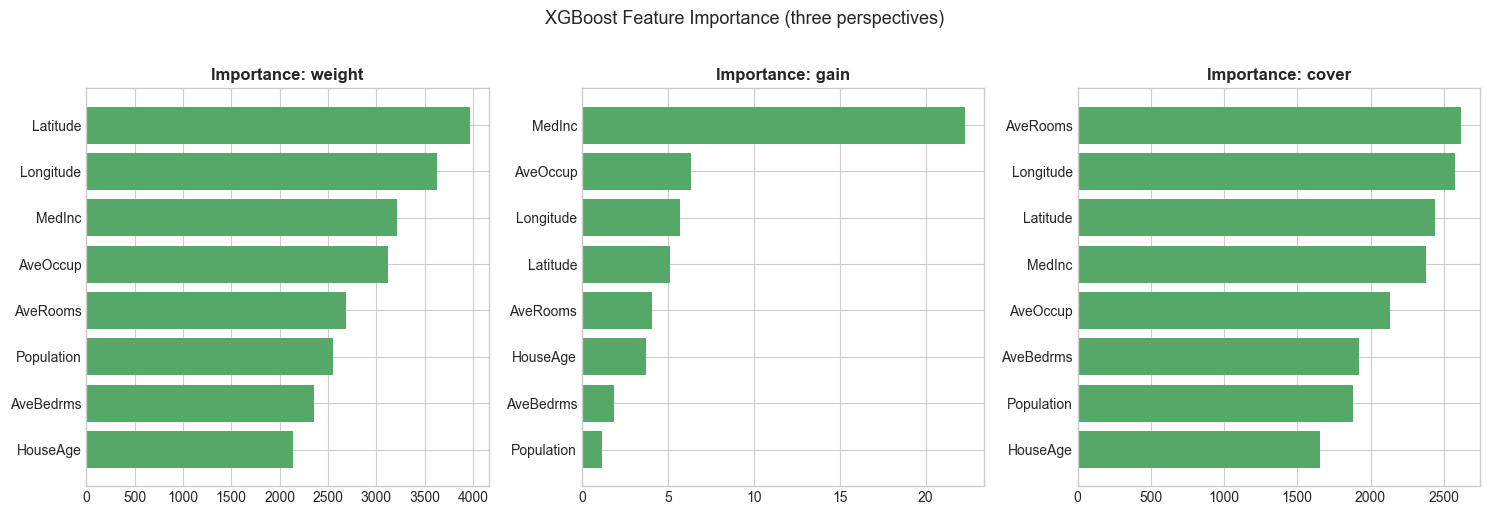

In [17]:
# ── XGBoost: Feature importance ──────────────────────────────────
# XGBoost supports multiple importance types:
#  'weight'    = # times feature used in splits
#  'gain'      = average gain of splits using this feature  ← most informative
#  'cover'     = average # samples covered

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, imp_type in zip(axes, ["weight", "gain", "cover"]):
    imp = xgb_model.get_score(importance_type=imp_type)
    sorted_imp = dict(sorted(imp.items(), key=lambda x: x[1]))
    ax.barh(list(sorted_imp.keys()), list(sorted_imp.values()), color=COLORS[2])
    ax.set_title(f"Importance: {imp_type}", fontsize=12, fontweight='bold')

plt.suptitle("XGBoost Feature Importance (three perspectives)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# 🔧 TRY: regularization effects
# Strong L2:
# p = xgb_params.copy(); p["lambda"] = 10; p["alpha"] = 1
# Run the training block above with new params and compare RMSE

# 🔧 TRY: depth vs. num_rounds tradeoff
# Shallow trees (max_depth=3) + more rounds vs deep trees (max_depth=8) + few rounds


---
## 8. LightGBM — Light Gradient Boosting Machine

LightGBM (Ke et al., Microsoft, 2017) solves the **scalability bottleneck** in GBM/XGBoost.

### Two Key Innovations

#### 8.1 Gradient-based One-Side Sampling (GOSS)

Standard GBM needs to compute gain for every split over all $n$ samples → $O(n \cdot p)$ per level.

**Observation:** Samples with small gradients contribute little to the gain calculation.

GOSS keeps all instances with **large gradients** (top $a \cdot 100\%$), and **randomly samples** $b \cdot 100\%$ of small-gradient instances (with amplification factor $(1-a)/b$ to compensate):

$$V_j(d) = \frac{1}{n}\left( \left(\sum_{x_i \in A_L} g_i - \frac{1-a}{b}\sum_{x_i \in B_L} g_i\right)^2 / (n_l^j)^2 + \ldots \right)$$

This keeps the variance of gain estimates low while massively reducing computation.

#### 8.2 Exclusive Feature Bundling (EFB)

High-dimensional sparse data often has **mutually exclusive features** (can't both be nonzero).

EFB bundles such features into single ones → reduces $p$ to $\tilde{p} \ll p$

**Combined effect:** From $O(\#\text{data} \times \#\text{features})$ to $O(\#\text{data} \times \tilde{p} \times \text{sample\_fraction})$

#### 8.3 Leaf-wise vs Level-wise Tree Growth

| XGBoost / sklearn GBM | LightGBM |
|---|---|
| Level-wise (breadth-first) | Leaf-wise (best-first) |
| All leaves at same depth | Grows the leaf with max delta-loss |
| More balanced | Less balanced → can overfit on small data |
| Safer for small datasets | Much faster, better accuracy on large data |

$$\text{Best leaf} = \arg\max_{\text{leaf}} \Delta\text{Loss}$$

**Use `num_leaves`** (not `max_depth`) as the main complexity control.  
Rule of thumb: `num_leaves` $< 2^{\text{max\_depth}}$


LightGBM  best iteration: 311
LightGBM  RMSE=0.4382  R²=0.8534


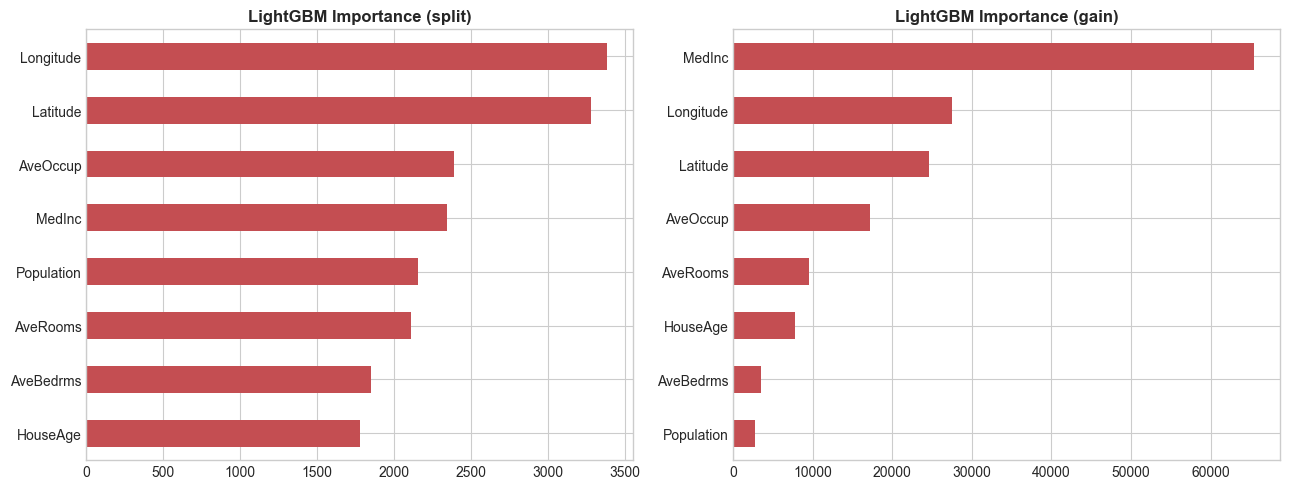

In [18]:
# ── LightGBM: native API ──────────────────────────────────────────
ltrain = lgb.Dataset(X_train, label=y_train)
lval   = lgb.Dataset(X_val,   label=y_val,   reference=ltrain)

lgb_params = {
    "objective"      : "regression",
    "metric"         : "rmse",
    "learning_rate"  : 0.05,
    "num_leaves"     : 63,          # main complexity param (default 31, max ~255)
    "max_depth"      : -1,          # -1 = no limit; control via num_leaves instead
    "min_data_in_leaf": 20,         # regularization: min samples per leaf
    "feature_fraction": 0.8,        # % of features per tree (like colsample_bytree)
    "bagging_fraction": 0.8,        # % of data per tree
    "bagging_freq"   : 5,           # apply bagging every k iterations
    "lambda_l1"      : 0.0,
    "lambda_l2"      : 0.1,
    "verbose"        : -1,
    "seed"           : SEED,
}

callbacks = [lgb.early_stopping(30, verbose=False), lgb.log_evaluation(period=-1)]

lgb_model = lgb.train(
    lgb_params,
    ltrain,
    num_boost_round=1000,
    valid_sets=[ltrain, lval],
    valid_names=["train", "val"],
    callbacks=callbacks,
)

lgb_preds = lgb_model.predict(X_test, num_iteration=lgb_model.best_iteration)
lgb_rmse  = np.sqrt(mean_squared_error(y_test, lgb_preds))
lgb_r2    = r2_score(y_test, lgb_preds)
results["LightGBM"] = {"RMSE": lgb_rmse, "MAE": mean_absolute_error(y_test, lgb_preds), "R²": lgb_r2}

print(f"LightGBM  best iteration: {lgb_model.best_iteration}")
print(f"LightGBM  RMSE={lgb_rmse:.4f}  R²={lgb_r2:.4f}")

# ── Feature importance ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, imp_type in zip(axes, ["split", "gain"]):
    imp = pd.Series(lgb_model.feature_importance(importance_type=imp_type),
                    index=X.columns).sort_values(ascending=True)
    imp.plot.barh(ax=ax, color=COLORS[3])
    ax.set_title(f"LightGBM Importance ({imp_type})", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# 🔧 TRY: leaf-wise overfitting on small datasets
# Reduce training data and increase num_leaves — watch test RMSE blow up
# X_small, _, y_small, _ = train_test_split(X_train, y_train, train_size=0.05, random_state=SEED)
# Then retrain with num_leaves=255 and compare

# 🔧 TRY: increase num_leaves from 31 → 127 → 511 and track RMSE


🔥 SCALABILITY BENCHMARK: Training time vs dataset size
Sizes to benchmark: [10438, 11184, 11929, 12675]

Testing on 10,438 samples...
   XGBoost: 0.14s  │  LightGBM: 0.19s  │  CatBoost: 0.13s  │  sklearn: 2.49s

Testing on 11,184 samples...
   XGBoost: 0.12s  │  LightGBM: 0.20s  │  CatBoost: 0.12s  │  sklearn: 2.53s

Testing on 11,929 samples...
   XGBoost: 0.09s  │  LightGBM: 0.21s  │  CatBoost: 0.12s  │  sklearn: 2.77s

Testing on 12,675 samples...
   XGBoost: 0.09s  │  LightGBM: 0.25s  │  CatBoost: 0.16s  │  sklearn: 2.93s


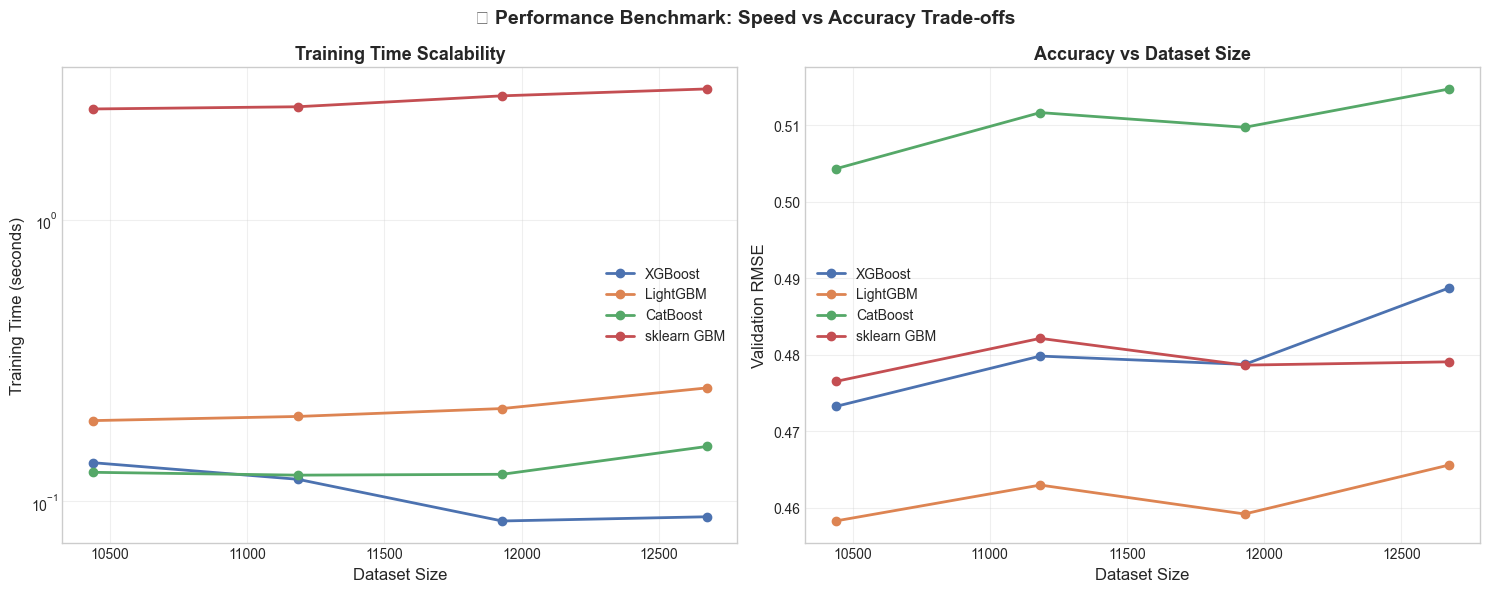


🏆 SPEED RANKING (on 12,675 samples):
   1. XGBoost     : 0.09s
   2. CatBoost    : 0.16s
   3. LightGBM    : 0.25s
   4. sklearn GBM : 2.93s

📊 ACCURACY RANKING (by final RMSE):
   1. LightGBM    : 0.4656
   2. sklearn GBM : 0.4791
   3. XGBoost     : 0.4888
   4. CatBoost    : 0.5147


In [23]:
# ── ⚡ Speed & Scalability Benchmark ──────────────────────────────
print("🔥 SCALABILITY BENCHMARK: Training time vs dataset size")
print("=" * 60)

# Create datasets of different sizes
#sizes = [1000, 5000, 10000, 15000] # Should not exceed training set size
sizes = [int(p * len(X_train)) for p in [0.7, 0.75, 0.8, 0.85]]
print(f"Sizes to benchmark: {sizes}")
algorithms = ['XGBoost', 'LightGBM', 'CatBoost', 'sklearn GBM']
timing_results = {alg: [] for alg in algorithms}
rmse_results = {alg: [] for alg in algorithms}

for size in sizes:
    print(f"\nTesting on {size:,} samples...")
    
    # Create subsets for training and validation
    X_sub, X_sub_val, y_sub, y_sub_val = train_test_split(X_train, y_train,
                                                           train_size=size,
                                                           random_state=SEED)
    
    # XGBoost
    start = time.time()
    dtrain_bench = xgb.DMatrix(X_sub, label=y_sub)
    dval_bench = xgb.DMatrix(X_sub_val, label=y_sub_val)
    xgb_bench = xgb.train({'objective': 'reg:squarederror', 'learning_rate': 0.1,
                           'max_depth': 6, 'seed': SEED},
                          dtrain_bench, num_boost_round=100)
    xgb_time = time.time() - start
    xgb_pred = xgb_bench.predict(dval_bench)
    xgb_rmse = np.sqrt(mean_squared_error(y_sub_val, xgb_pred))
    timing_results['XGBoost'].append(xgb_time)
    rmse_results['XGBoost'].append(xgb_rmse)
    
    # LightGBM
    start = time.time()
    ltrain_bench = lgb.Dataset(X_sub, label=y_sub)
    lgb_bench = lgb.train({'objective': 'regression', 'learning_rate': 0.1,
                           'num_leaves': 63, 'seed': SEED},
                          ltrain_bench, num_boost_round=100)
    lgb_time = time.time() - start
    lgb_pred = lgb_bench.predict(X_sub_val)
    lgb_rmse = np.sqrt(mean_squared_error(y_sub_val, lgb_pred))
    timing_results['LightGBM'].append(lgb_time)
    rmse_results['LightGBM'].append(lgb_rmse)
    
    # CatBoost
    start = time.time()
    cb_bench = cb.CatBoostRegressor(iterations=100, learning_rate=0.1,
                                    depth=6, verbose=0, random_seed=SEED)
    cb_bench.fit(X_sub, y_sub)
    cb_time = time.time() - start
    cb_pred = cb_bench.predict(X_sub_val)
    cb_rmse = np.sqrt(mean_squared_error(y_sub_val, cb_pred))
    timing_results['CatBoost'].append(cb_time)
    rmse_results['CatBoost'].append(cb_rmse)
    
    # sklearn GBM
    start = time.time()
    sklearn_bench = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1,
                                              max_depth=6, random_state=SEED)
    sklearn_bench.fit(X_sub, y_sub)
    sklearn_time = time.time() - start
    sklearn_pred = sklearn_bench.predict(X_sub_val)
    sklearn_rmse = np.sqrt(mean_squared_error(y_sub_val, sklearn_pred))
    timing_results['sklearn GBM'].append(sklearn_time)
    rmse_results['sklearn GBM'].append(sklearn_rmse)
    
    print(f"   XGBoost: {xgb_time:.2f}s  │  LightGBM: {lgb_time:.2f}s  │  " + 
          f"CatBoost: {cb_time:.2f}s  │  sklearn: {sklearn_time:.2f}s")

# Plot results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Training time
for i, (alg, times) in enumerate(timing_results.items()):
    ax1.plot(sizes, times, 'o-', linewidth=2, markersize=6, 
             color=COLORS[i], label=alg)

ax1.set_xlabel('Dataset Size', fontsize=12)
ax1.set_ylabel('Training Time (seconds)', fontsize=12)
ax1.set_title('Training Time Scalability', fontsize=13, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_yscale('log')

# RMSE comparison
for i, (alg, rmses) in enumerate(rmse_results.items()):
    ax2.plot(sizes, rmses, 'o-', linewidth=2, markersize=6,
             color=COLORS[i], label=alg)

ax2.set_xlabel('Dataset Size', fontsize=12)
ax2.set_ylabel('Validation RMSE', fontsize=12)
ax2.set_title('Accuracy vs Dataset Size', fontsize=13, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('🚀 Performance Benchmark: Speed vs Accuracy Trade-offs', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Speed summary
print(f"\n🏆 SPEED RANKING (on {sizes[-1]:,} samples):")
final_times = [(alg, times[-1]) for alg, times in timing_results.items()]
final_times.sort(key=lambda x: x[1])
for rank, (alg, time_taken) in enumerate(final_times, 1):
    print(f"   {rank}. {alg:<12}: {time_taken:.2f}s")

print(f"\n📊 ACCURACY RANKING (by final RMSE):")
final_rmse = [(alg, rmses[-1]) for alg, rmses in rmse_results.items()]
final_rmse.sort(key=lambda x: x[1])
for rank, (alg, rmse_val) in enumerate(final_rmse, 1):
    print(f"   {rank}. {alg:<12}: {rmse_val:.4f}")

---
## 9. CatBoost — Categorical Boosting

CatBoost (Prokhorenkova et al., Yandex, 2018) focuses on two problems:

### 9.1 The Target Leakage Problem in Categorical Encoding

Standard target encoding: $\text{enc}(x_k) = \frac{\sum_{j: x_j=x_k} y_j}{|\{j: x_j=x_k\}|}$

**Problem:** when computing the encoding for sample $i$, using $y_i$ itself leaks the target → **target leakage / conditional shift**.

The model learns a feature that "knows" $y_i$ → overfitting on train, poor generalization.

### 9.2 Ordered Boosting (the Solution)

CatBoost uses a **random permutation** $\sigma$ of the training data.

For sample $i$ at boosting iteration $b$, the model $M_{b,\sigma}^i$ is only trained on samples **preceding** $i$ in $\sigma$:

$$M_{b,\sigma}^i = \text{train on } \{j : \sigma(j) < \sigma(i)\}$$

The gradient for sample $i$ is computed using $M_{b,\sigma}^i$ (which has **never seen** sample $i$):
$$r_i^{(b)} = -\nabla L(y_i, M_{b,\sigma}^i(x_i))$$

This produces **unbiased** gradient estimates → no overfitting from target leakage.

**Ordered target encoding:** Similarly, the categorical feature encoding for $x_i$ is computed only from samples before $\sigma(i)$:

$$\hat{x}_i^k = \frac{\sum_{j<\sigma(i)} \mathbf{1}[x_j^k = x_i^k] \cdot y_j + a \cdot P}{\sum_{j<\sigma(i)} \mathbf{1}[x_j^k = x_i^k] + a}$$

where $P$ is the global target prior and $a$ is a smoothing parameter.

**Other CatBoost features:**
- Symmetric (oblivious) trees → fast CPU inference, built-in regularization
- GPU training with `task_type='GPU'`
- Native handling of `cat_features` — no preprocessing needed


CatBoost  best iteration: 997
CatBoost  RMSE=0.4554  R²=0.8417


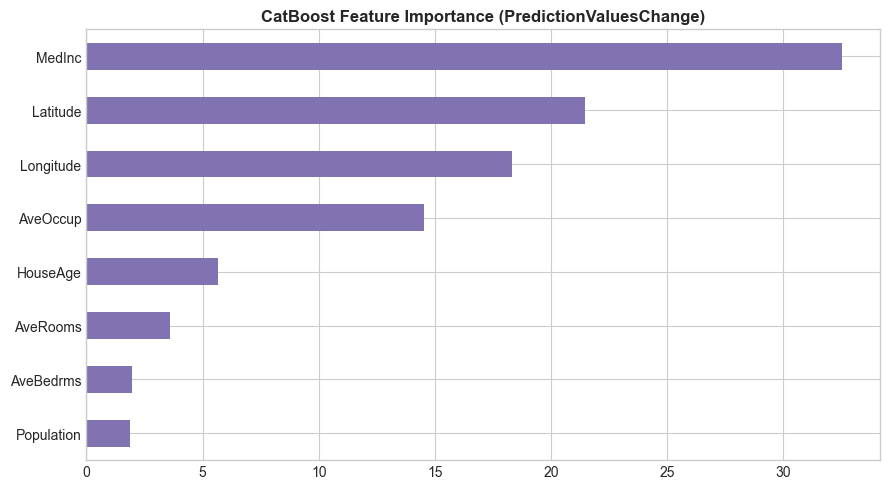

In [24]:
# ── CatBoost ──────────────────────────────────────────────────────
# (California Housing has no categorical features, but CatBoost still competes
#  on numerical data due to ordered boosting's bias reduction)

cb_model = cb.CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=3.0,       # L2 regularization
    bagging_temperature=1, # Bayesian bootstrap (0=no bagging, 1=Poisson, higher=more stochastic)
    random_strength=1,     # randomness for split scoring
    border_count=254,      # number of bins for numerical features
    eval_metric="RMSE",
    early_stopping_rounds=30,
    random_seed=SEED,
    verbose=0,
)

cb_model.fit(
    X_train, y_train,
    eval_set=(X_val, y_val),
    use_best_model=True,
)

cb_preds = cb_model.predict(X_test)
cb_rmse  = np.sqrt(mean_squared_error(y_test, cb_preds))
cb_r2    = r2_score(y_test, cb_preds)
results["CatBoost"] = {"RMSE": cb_rmse, "MAE": mean_absolute_error(y_test, cb_preds), "R²": cb_r2}

print(f"CatBoost  best iteration: {cb_model.best_iteration_}")
print(f"CatBoost  RMSE={cb_rmse:.4f}  R²={cb_r2:.4f}")

# ── Feature importance ────────────────────────────────────────────
cb_imp = pd.Series(cb_model.get_feature_importance(), index=X.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
cb_imp.plot.barh(ax=ax, color=COLORS[4])
ax.set_title("CatBoost Feature Importance (PredictionValuesChange)", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# 🔧 TRY: show CatBoost advantage on datasets with many categories
# Load a dataset with categorical columns and pass cat_features=[...] to .fit()
# CatBoost will outperform XGBoost/LGBM without manual encoding


---
## 10. Head-to-Head Comparison

Now let's compare all models systematically across metrics, prediction quality, and residuals.


MODEL COMPARISON — California Housing (Test Set)
                               RMSE     MAE      R²
LightGBM                     0.4382  0.2894  0.8534
XGBoost                      0.4484  0.2963  0.8466
CatBoost                     0.4554  0.3021  0.8417
Gradient Boosting (sklearn)  0.4933  0.3358  0.8143
Random Forest (200 trees)    0.5089  0.3441  0.8024
Bagging (100 trees)          0.5132  0.3346  0.7990
Decision Tree                0.6620  0.4578  0.6656
AdaBoost (100 stumps)        0.8610  0.7405  0.4343


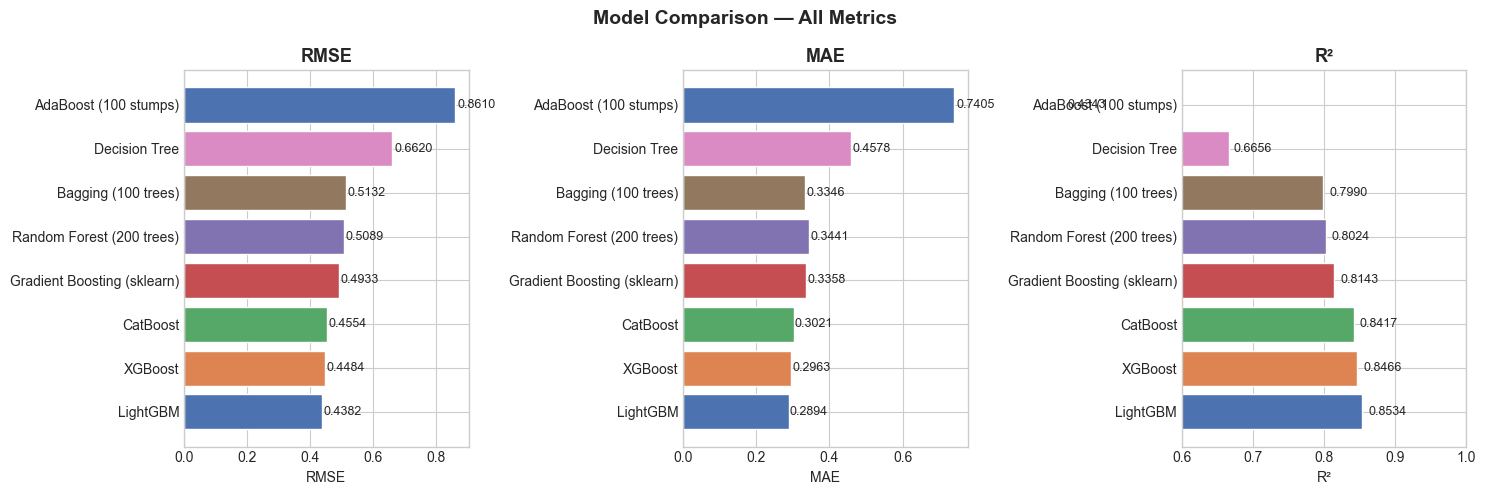

In [25]:
# ── Summary table ────────────────────────────────────────────────
results_df = pd.DataFrame(results).T.round(4)
results_df = results_df.sort_values("RMSE")

print("=" * 55)
print("MODEL COMPARISON — California Housing (Test Set)")
print("=" * 55)
print(results_df.to_string())
print("=" * 55)

# ── Bar chart ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, metric in zip(axes, ["RMSE", "MAE", "R²"]):
    vals = results_df[metric]
    colors = [COLORS[i % len(COLORS)] for i in range(len(vals))]
    
    if metric == "R²":
        bars = ax.barh(vals.index, vals.values, color=colors, edgecolor='white')
        ax.set_xlim(0.6, 1.0)
    else:
        bars = ax.barh(vals.index, vals.values, color=colors, edgecolor='white')
    
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_xlabel(metric)
    
    for bar, v in zip(bars, vals.values):
        ax.text(bar.get_width() + bar.get_width()*0.01, bar.get_y() + bar.get_height()/2,
                f"{v:.4f}", va='center', fontsize=9)

plt.suptitle("Model Comparison — All Metrics", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


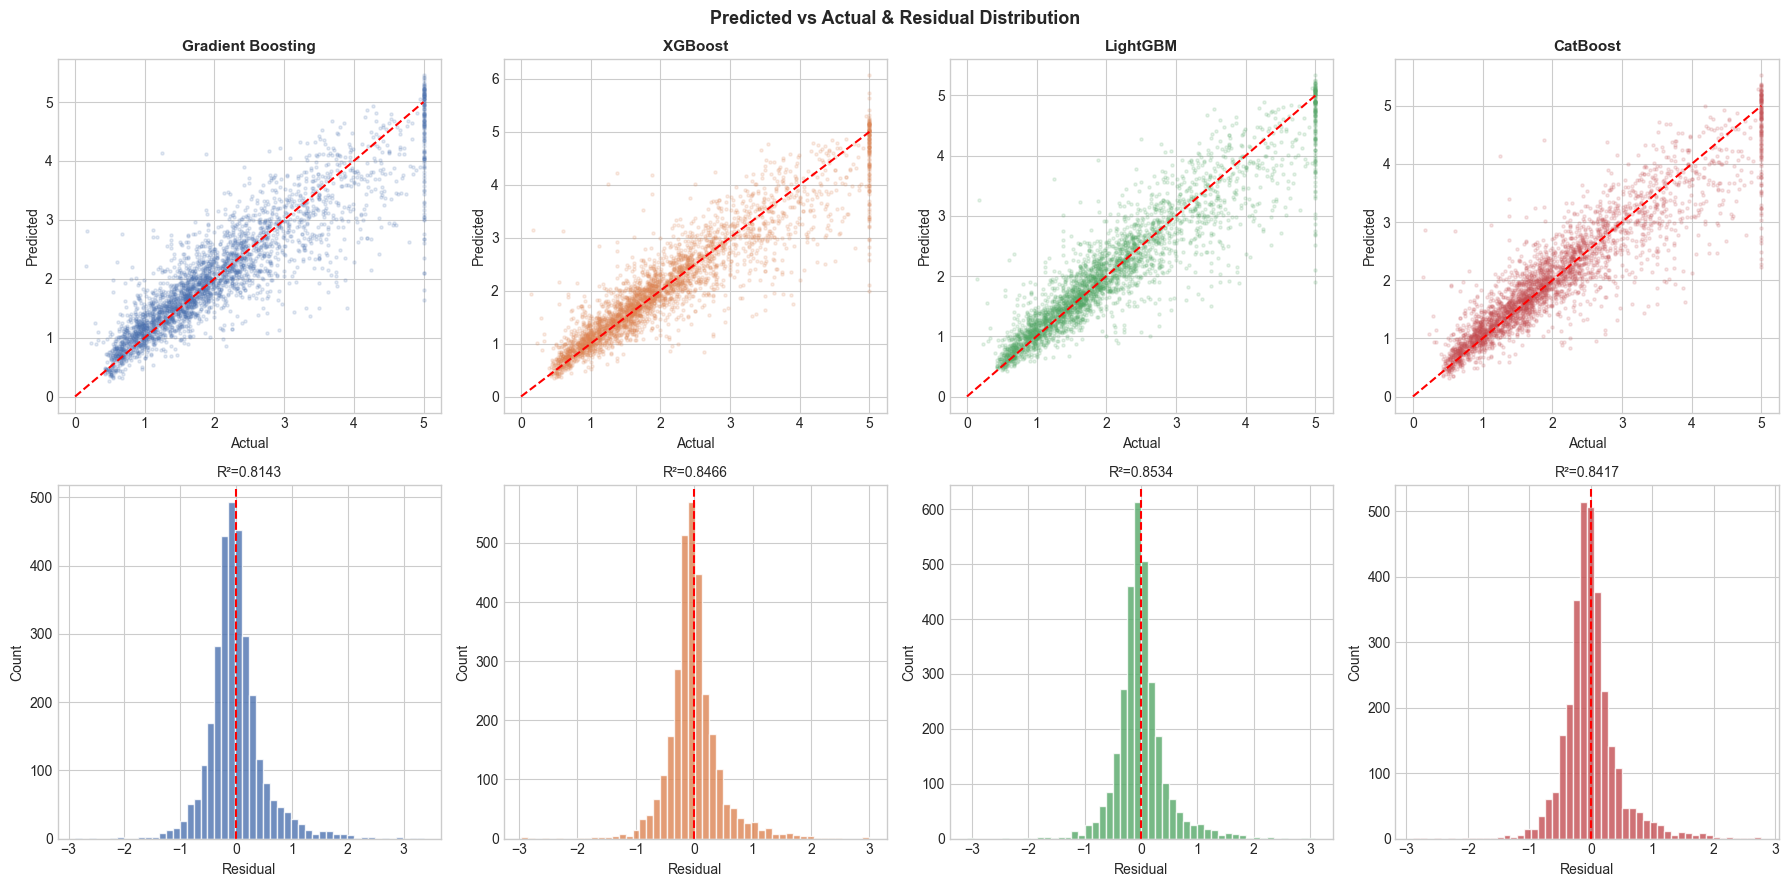

In [26]:
# ── Residual analysis ─────────────────────────────────────────────
# Collect predictions for all modern boosting models
model_preds = {
    "Gradient Boosting": gbm.predict(X_test),
    "XGBoost"          : xgb_preds,
    "LightGBM"         : lgb_preds,
    "CatBoost"         : cb_preds,
}

fig, axes = plt.subplots(2, 4, figsize=(18, 9))

for col, (name, preds) in enumerate(model_preds.items()):
    residuals = y_test.values - preds
    
    # Predicted vs Actual
    ax = axes[0, col]
    ax.scatter(y_test, preds, alpha=0.15, s=5, color=COLORS[col])
    ax.plot([0, 5], [0, 5], "r--", lw=1.5)
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")
    
    # Residual distribution
    ax = axes[1, col]
    ax.hist(residuals, bins=50, color=COLORS[col], alpha=0.8, edgecolor='white')
    ax.axvline(0, color='red', lw=1.5, ls='--')
    ax.set_xlabel("Residual")
    ax.set_ylabel("Count")
    r2 = r2_score(y_test, preds)
    ax.set_title(f"R²={r2:.4f}", fontsize=10)

plt.suptitle("Predicted vs Actual & Residual Distribution", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


🔬 ADVANCED EXPERIMENTS FOR DEEP UNDERSTANDING
\n🔹 Learning Curves Analysis:
This helps understand if models suffer from high bias or high variance


/usr/local/Cellar/python@3.11/3.11.14/Frameworks/Python.framework/Versions/3.11/lib/python3.11/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/usr/local/Cellar/python@3.11/3.11.14/Frameworks/Python.framework/Versions/3.11/lib/python3.11/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/usr/local/Cellar/python@3.11/3.11.14/Frameworks/Python.framework/Versions/3.11/lib/python3.11/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://se

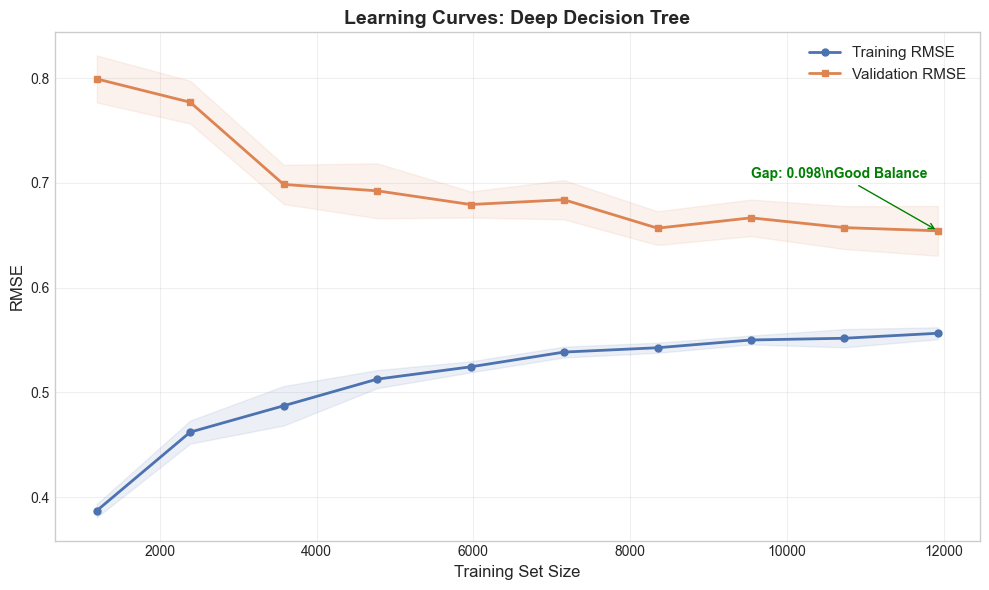

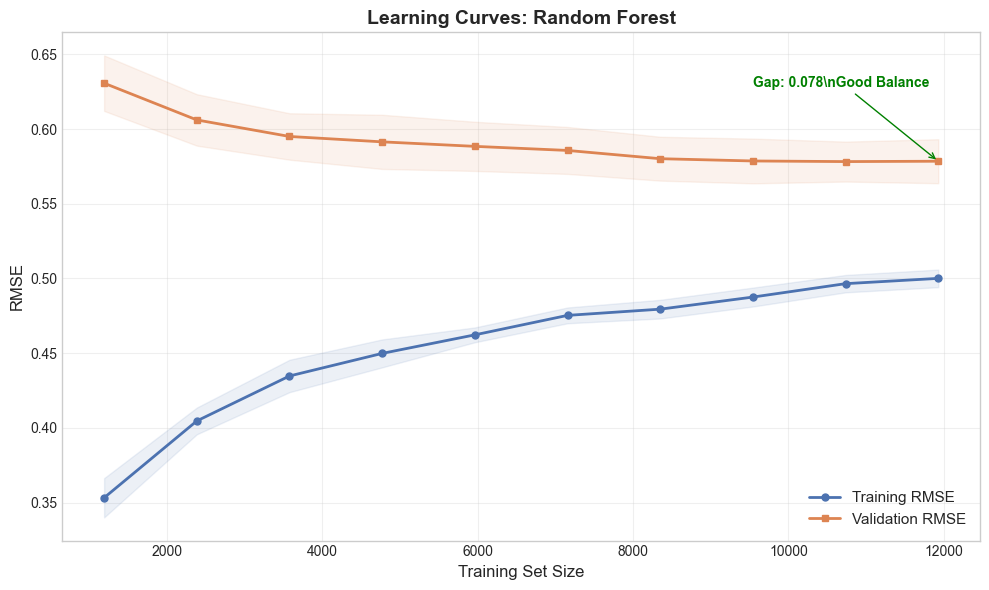

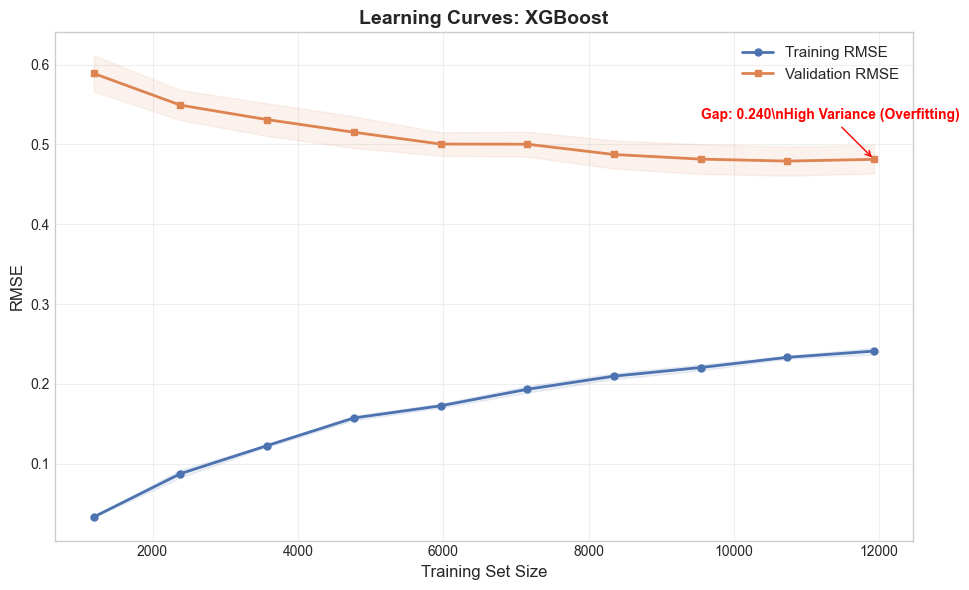

\n📊 Bias-Variance Summary:
Deep Decision Tree  : Train-Val gap = 0.0978 (Good Balance)
Random Forest       : Train-Val gap = 0.0784 (Good Balance)
XGBoost             : Train-Val gap = 0.2402 (High Variance)
\n=======================================================
🔹 Feature Importance Stability Analysis
How consistent are feature rankings across different random seeds?
\nAnalyzing Random Forest stability...
\nAnalyzing XGBoost stability...


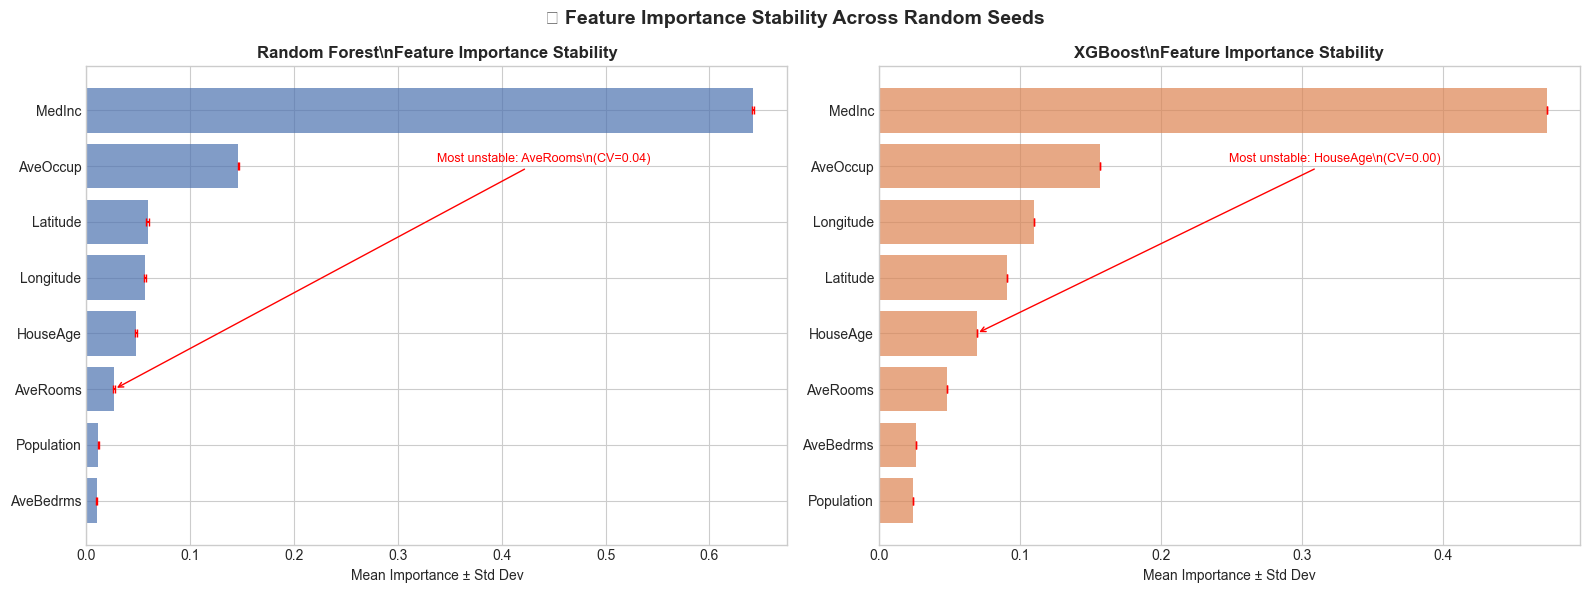

\n💡 Interpretation:
• Low CV (Coefficient of Variation) = Stable feature importance
• High CV = Feature importance varies significantly across runs
• More stable features are generally more trustworthy for interpretation
\n=======================================================
🔹 Hyperparameter Sensitivity Analysis
How sensitive is model performance to hyperparameter changes?
Analyzing sensitivity to max_depth...
Analyzing sensitivity to learning_rate...
Analyzing sensitivity to n_estimators...


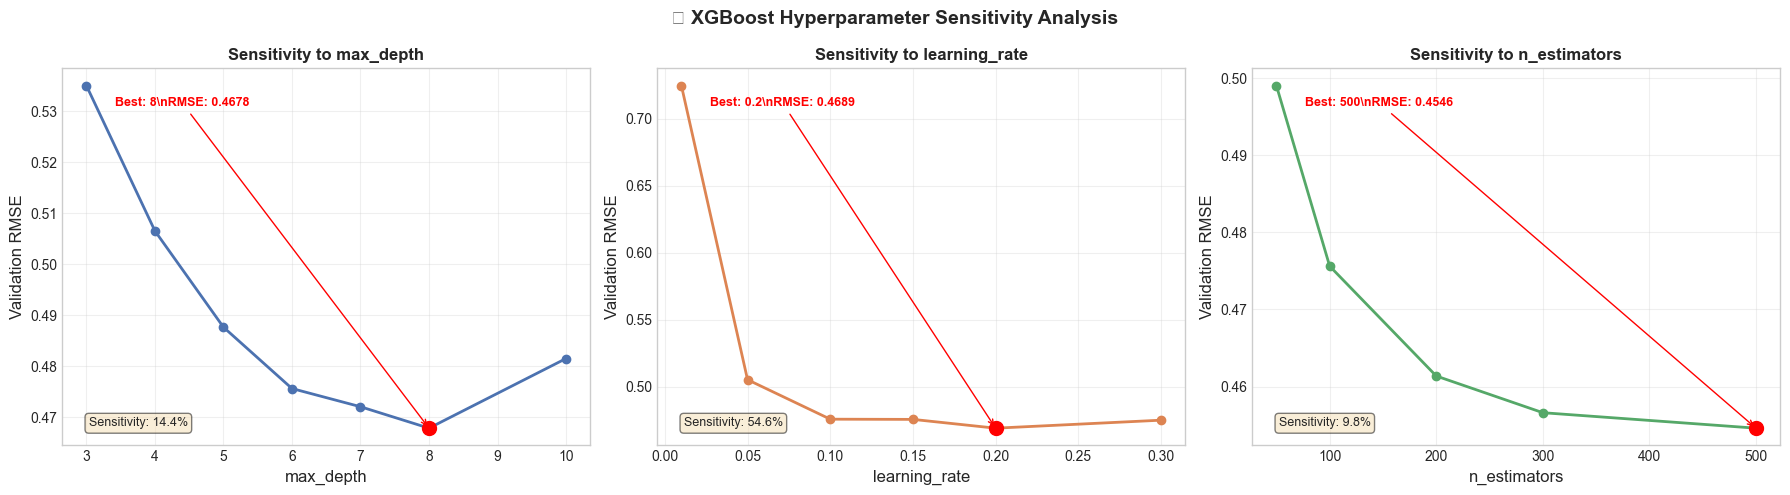

\n🎯 Sensitivity Interpretation:
• High sensitivity = Small changes in parameter cause large performance changes
• Low sensitivity = Parameter is robust, performance is stable
• Focus tuning efforts on high-sensitivity parameters for maximum impact
\n=======================================================
🎓 KEY TAKEAWAYS FROM EXPERIMENTS:
1. Learning curves help diagnose bias vs variance problems
2. Feature importance can be unstable - use multiple runs for robustness
3. Some hyperparameters are more critical than others - prioritize tuning
4. Always validate findings across different random seeds and data splits


In [27]:
# ── 🧪 Advanced Experimentation Section ─────────────────────────────
print("🔬 ADVANCED EXPERIMENTS FOR DEEP UNDERSTANDING")
print("=" * 55)

# ── Experiment 1: Overfitting Analysis with Learning Curves ──────
def plot_learning_curves(model, model_name, train_sizes=None):
    """Plot learning curves to analyze bias-variance tradeoff"""
    if train_sizes is None:
        train_sizes = np.linspace(0.1, 1.0, 10)
    
    train_sizes_abs, train_scores, val_scores = learning_curve(
        model, X_train, y_train, 
        train_sizes=train_sizes,
        cv=5, 
        scoring='neg_root_mean_squared_error',
        n_jobs=-1,
        random_state=SEED
    )
    
    # Convert to positive RMSE
    train_scores = -train_scores
    val_scores = -val_scores
    
    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    val_mean = val_scores.mean(axis=1)
    val_std = val_scores.std(axis=1)
    
    plt.figure(figsize=(10, 6))
    
    # Plot training scores
    plt.fill_between(train_sizes_abs, train_mean - train_std,
                     train_mean + train_std, alpha=0.1, color=COLORS[0])
    plt.plot(train_sizes_abs, train_mean, 'o-', color=COLORS[0],
             label="Training RMSE", linewidth=2, markersize=5)
    
    # Plot validation scores
    plt.fill_between(train_sizes_abs, val_mean - val_std,
                     val_mean + val_std, alpha=0.1, color=COLORS[1])
    plt.plot(train_sizes_abs, val_mean, 's-', color=COLORS[1],
             label="Validation RMSE", linewidth=2, markersize=5)
    
    plt.xlabel('Training Set Size', fontsize=12)
    plt.ylabel('RMSE', fontsize=12)
    plt.title(f'Learning Curves: {model_name}', fontsize=14, fontweight='bold')
    plt.legend(loc='best', fontsize=11)
    plt.grid(True, alpha=0.3)
    
    # Analyze bias/variance
    final_gap = val_mean[-1] - train_mean[-1]
    if final_gap > 0.1:
        bias_variance = "High Variance (Overfitting)"
        color_annotation = 'red'
    elif train_mean[-1] > 0.8:  # Assuming RMSE > 0.8 is high bias
        bias_variance = "High Bias (Underfitting)" 
        color_annotation = 'orange'
    else:
        bias_variance = "Good Balance"
        color_annotation = 'green'
        
    plt.annotate(f'Gap: {final_gap:.3f}\\n{bias_variance}',
                xy=(train_sizes_abs[-1], val_mean[-1]),
                xytext=(train_sizes_abs[-3], val_mean[-1] + 0.05),
                arrowprops=dict(arrowstyle='->', color=color_annotation),
                fontsize=10, color=color_annotation, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    return final_gap

print("\\n🔹 Learning Curves Analysis:")
print("This helps understand if models suffer from high bias or high variance")

models_to_analyze = [
    (DecisionTreeRegressor(max_depth=8, random_state=SEED), "Deep Decision Tree"),
    (RandomForestRegressor(n_estimators=100, max_depth=8, random_state=SEED), "Random Forest"),
    (xgb.XGBRegressor(max_depth=6, n_estimators=100, random_state=SEED), "XGBoost"),
]

bias_variance_results = {}
for model, name in models_to_analyze:
    gap = plot_learning_curves(model, name)
    bias_variance_results[name] = gap
    
print("\\n📊 Bias-Variance Summary:")
for name, gap in bias_variance_results.items():
    status = "High Variance" if gap > 0.1 else "Good Balance"
    print(f"{name:<20}: Train-Val gap = {gap:.4f} ({status})")

# ── Experiment 2: Feature Importance Stability ─────────────────────
print("\\n" + "="*55)
print("🔹 Feature Importance Stability Analysis")
print("How consistent are feature rankings across different random seeds?")

def importance_stability_analysis(model_class, model_params, n_runs=10):
    """Analyze how stable feature importance rankings are across random runs"""
    importance_matrix = []
    
    for run in range(n_runs):
        # Use different random seed for each run
        params_copy = model_params.copy()
        params_copy['random_state'] = SEED + run
        
        model = model_class(**params_copy)
        model.fit(X_train, y_train)
        
        # Get feature importance
        if hasattr(model, 'feature_importances_'):
            importance = model.feature_importances_
        else:  # For XGBoost
            importance = np.array(list(model.get_booster().get_score(importance_type='gain').values()))
            
        importance_matrix.append(importance)
    
    importance_matrix = np.array(importance_matrix)
    
    # Calculate stability metrics
    mean_importance = importance_matrix.mean(axis=0)
    std_importance = importance_matrix.std(axis=0)
    cv_importance = std_importance / (mean_importance + 1e-10)  # Coefficient of variation
    
    return mean_importance, std_importance, cv_importance

# Analyze stability for different models
stability_models = {
    'Random Forest': (RandomForestRegressor, {'n_estimators': 100, 'max_depth': 8}),
    'XGBoost': (xgb.XGBRegressor, {'n_estimators': 100, 'max_depth': 6, 'objective': 'reg:squarederror'}),
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, (model_name, (model_class, params)) in enumerate(stability_models.items()):
    print(f"\\nAnalyzing {model_name} stability...")
    mean_imp, std_imp, cv_imp = importance_stability_analysis(model_class, params)
    
    # Create DataFrame for easier plotting
    stability_df = pd.DataFrame({
        'Feature': X.columns,
        'Mean_Importance': mean_imp,
        'Std_Importance': std_imp,
        'CV_Importance': cv_imp
    }).sort_values('Mean_Importance', ascending=True)
    
    # Plot
    ax = axes[idx]
    bars = ax.barh(stability_df['Feature'], stability_df['Mean_Importance'], 
                   color=COLORS[idx], alpha=0.7)
    ax.errorbar(stability_df['Mean_Importance'], range(len(stability_df)), 
                xerr=stability_df['Std_Importance'], fmt='none', color='red', capsize=3)
    
    ax.set_title(f'{model_name}\\nFeature Importance Stability', fontsize=12, fontweight='bold')
    ax.set_xlabel('Mean Importance ± Std Dev')
    
    # Highlight most unstable feature
    max_cv_idx = stability_df['CV_Importance'].idxmax()
    most_unstable = stability_df.loc[max_cv_idx, 'Feature']
    max_cv = stability_df.loc[max_cv_idx, 'CV_Importance']
    
    ax.annotate(f'Most unstable: {most_unstable}\\n(CV={max_cv:.2f})', 
                xy=(stability_df.loc[max_cv_idx, 'Mean_Importance'], 
                    list(stability_df['Feature']).index(most_unstable)),
                xytext=(0.5, 0.8), textcoords='axes fraction',
                arrowprops=dict(arrowstyle='->', color='red'),
                fontsize=9, color='red')

plt.suptitle('🔍 Feature Importance Stability Across Random Seeds', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\\n💡 Interpretation:")
print("• Low CV (Coefficient of Variation) = Stable feature importance")
print("• High CV = Feature importance varies significantly across runs")
print("• More stable features are generally more trustworthy for interpretation")

# ── Experiment 3: Hyperparameter Sensitivity Analysis ──────────────
print("\\n" + "="*55)
print("🔹 Hyperparameter Sensitivity Analysis")
print("How sensitive is model performance to hyperparameter changes?")

def sensitivity_analysis(param_name, param_values, base_params, model_class=xgb.XGBRegressor):
    """Analyze sensitivity to a specific hyperparameter"""
    rmse_scores = []
    
    for param_value in param_values:
        params = base_params.copy()
        params[param_name] = param_value
        
        model = model_class(**params)
        model.fit(X_train, y_train)
        preds = model.predict(X_val)
        rmse = np.sqrt(mean_squared_error(y_val, preds))
        rmse_scores.append(rmse)
    
    return rmse_scores

# Base XGBoost parameters
base_xgb_params = {
    'n_estimators': 100,
    'max_depth': 6,
    'learning_rate': 0.1,
    'random_state': SEED,
    'objective': 'reg:squarederror'
}

# Parameters to analyze
sensitivity_params = {
    'max_depth': [3, 4, 5, 6, 7, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.15, 0.2, 0.3],
    'n_estimators': [50, 100, 200, 300, 500],
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (param_name, param_values) in enumerate(sensitivity_params.items()):
    print(f"Analyzing sensitivity to {param_name}...")
    
    rmse_scores = sensitivity_analysis(param_name, param_values, base_xgb_params)
    
    ax = axes[idx]
    ax.plot(param_values, rmse_scores, 'o-', color=COLORS[idx], linewidth=2, markersize=6)
    ax.set_xlabel(param_name, fontsize=12)
    ax.set_ylabel('Validation RMSE', fontsize=12)
    ax.set_title(f'Sensitivity to {param_name}', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # Highlight best value
    best_idx = np.argmin(rmse_scores)
    best_value = param_values[best_idx]
    best_rmse = rmse_scores[best_idx]
    
    ax.scatter(best_value, best_rmse, color='red', s=100, zorder=5)
    ax.annotate(f'Best: {best_value}\\nRMSE: {best_rmse:.4f}',
                xy=(best_value, best_rmse),
                xytext=(0.1, 0.9), textcoords='axes fraction',
                arrowprops=dict(arrowstyle='->', color='red'),
                fontsize=9, color='red', fontweight='bold')
    
    # Calculate sensitivity (range of RMSE values)
    rmse_range = max(rmse_scores) - min(rmse_scores)
    sensitivity = rmse_range / min(rmse_scores) * 100  # Percentage change
    
    ax.text(0.05, 0.05, f'Sensitivity: {sensitivity:.1f}%', 
            transform=ax.transAxes, fontsize=9,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('🎯 XGBoost Hyperparameter Sensitivity Analysis', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\\n🎯 Sensitivity Interpretation:")
print("• High sensitivity = Small changes in parameter cause large performance changes")  
print("• Low sensitivity = Parameter is robust, performance is stable")
print("• Focus tuning efforts on high-sensitivity parameters for maximum impact")

print("\\n" + "="*55)
print("🎓 KEY TAKEAWAYS FROM EXPERIMENTS:")
print("1. Learning curves help diagnose bias vs variance problems")
print("2. Feature importance can be unstable - use multiple runs for robustness") 
print("3. Some hyperparameters are more critical than others - prioritize tuning")
print("4. Always validate findings across different random seeds and data splits")

Computing SHAP values (may take ~30s)...


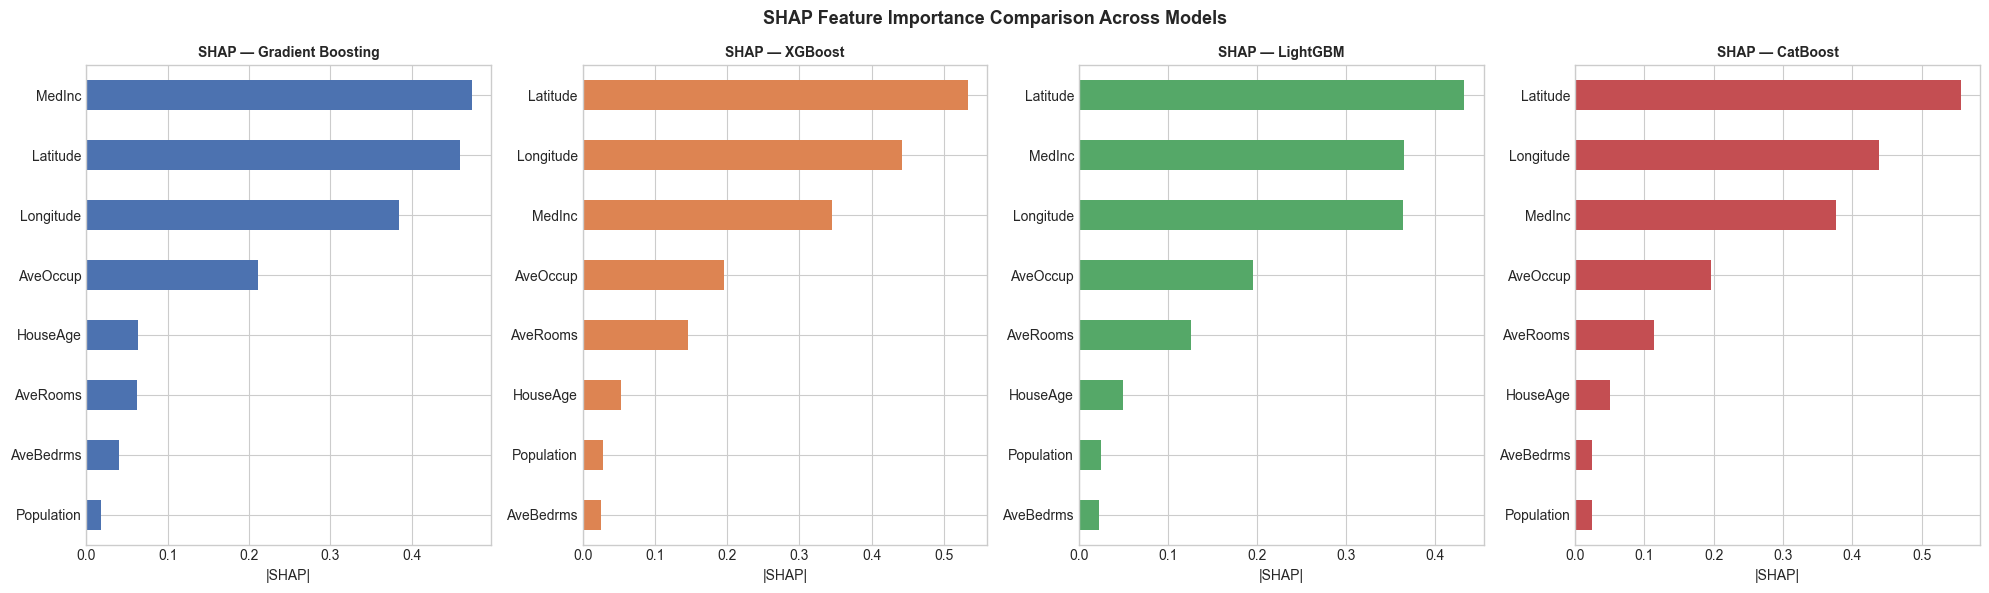

In [28]:
# ── SHAP comparison: which features matter most in each model? ─────
print("Computing SHAP values (may take ~30s)...")

fig, axes = plt.subplots(1, 4, figsize=(20, 6))

for ax, (name, preds) in zip(axes, model_preds.items()):
    if name == "Gradient Boosting":
        explainer = shap.TreeExplainer(gbm)
    elif name == "XGBoost":
        explainer = shap.TreeExplainer(xgb_model)
    elif name == "LightGBM":
        explainer = shap.TreeExplainer(lgb_model)
    else:
        explainer = shap.TreeExplainer(cb_model)
    
    shap_vals = explainer.shap_values(X_test.values if name == "CatBoost" else X_test)
    
    # Mean absolute SHAP value per feature
    mean_shap = np.abs(shap_vals).mean(axis=0)
    imp = pd.Series(mean_shap, index=X.columns).sort_values(ascending=True)
    imp.plot.barh(ax=ax, color=COLORS[list(model_preds.keys()).index(name)])
    ax.set_title(f"SHAP — {name}", fontsize=10, fontweight='bold')
    ax.set_xlabel("|SHAP|")

plt.suptitle("SHAP Feature Importance Comparison Across Models", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 11. Conceptual Summary

| Feature | sklearn GBM | XGBoost | LightGBM | CatBoost |
|---|---|---|---|---|
| **Split algorithm** | Exact | Exact / Approx | Histogram-based | Symmetric oblivious |
| **Tree growth** | Level-wise | Level-wise | **Leaf-wise** | Level-wise (symmetric) |
| **Regularization** | subsample, depth | L1, L2, γ, min_child_weight | L1, L2, num_leaves | L2, ordered boosting |
| **Missing values** | Needs imputation | **Native (directional)** | **Native** | **Native** |
| **Categoricals** | Manual encoding | Manual encoding | Manual encoding | **Native (ordered TE)** |
| **Speed (large data)** | Slow | Fast | **Fastest** | Fast |
| **Overfitting control** | 🟡 Moderate | 🟢 Good | 🟡 (leaf-wise risk) | 🟢 Good (ordered) |
| **Best for** | Baseline | General purpose | Very large datasets | Categorical-heavy data |

### When to Use What?

```
Many categorical features?          → CatBoost
Huge dataset, speed is critical?    → LightGBM
Good default, lots of community?    → XGBoost
Quick sklearn baseline?             → GradientBoostingRegressor
```

### Common Hyperparameter Interactions

```
learning_rate ↓  →  need more n_estimators (use early stopping)
max_depth ↑      →  more expressiveness, more overfitting risk
subsample < 1    →  reduces variance (stochastic gradient boosting)
lambda/reg ↑     →  stronger regularization, smoother trees
num_leaves ↑     →  more complex model (LightGBM specific)
```


---
# 📝 Homework Assignment — Gradient Boosting Deep Dive

**Estimated time:** 4–6 hours  
**Submission format:** Jupyter Notebook (`.ipynb`) + 1-page written reflection (PDF)  
**Dataset:** [Adult Income dataset](https://archive.ics.uci.edu/ml/datasets/adult) — predict whether a person earns >\$50K/year

```python
# Load the dataset
from ucimlrepo import fetch_ucirepo
adult = fetch_ucirepo(id=2)
X = adult.data.features
y = (adult.data.targets["income"] == ">50K").astype(int)
```

---

## Part A — Data Preparation (1.5 pts)

**A1 (0.5 pts):** Load the Adult dataset. Report class imbalance. Perform a stratified 70/15/15 train/val/test split. Show the class distribution in each split using a bar chart.

**A2 (0.5 pts):** Identify all categorical features. Apply **three different encoding strategies** to the same dataset: (a) label encoding, (b) one-hot encoding, (c) raw categoricals passed to CatBoost via `cat_features`. Do NOT apply the same encoding to all models — use the most appropriate one per model.

**A3 (0.5 pts):** Justify in writing (3–5 sentences) why passing raw categoricals to CatBoost is theoretically preferable to one-hot encoding in the context of ordered boosting.

---

## Part B — Model Training & Evaluation (3.5 pts)

**B1 (1.0 pt):** Train XGBoost, LightGBM, and CatBoost on the classification task. Use `early_stopping_rounds=30` and a validation set for all three. Report: number of trees at best iteration, AUC-ROC, F1-score, and log-loss on the **test set**. Present results in a formatted table.

**B2 (1.0 pt):** For **one model of your choice**, perform a manual grid search over at least **two hyperparameters** (at least 3 values each). Plot a heatmap showing how the **validation AUC-ROC** varies across the grid. Identify the best combination and re-evaluate on the test set.

> ⚠️ You must implement the grid search yourself using nested loops. Using `GridSearchCV` or `Optuna` for this part is not allowed.

**B3 (1.5 pts):** Implement the **learning rate schedule experiment**: train your best model three times with learning rates [0.001, 0.01, 0.1]. For each, find the best number of trees via early stopping. Plot **all three validation AUC curves** on the same figure. Discuss (5–8 sentences) the tradeoff between learning rate and number of trees, referencing the mathematical shrinkage concept from the tutorial.

---

## Part C — Model Interpretability (3.0 pts)

**C1 (1.0 pt):** Compute SHAP values for your best model on the test set. Produce two plots: (a) a beeswarm summary plot and (b) a SHAP dependence plot for the **two most important features**. Annotate each plot with a 2–3 sentence interpretation.

**C2 (1.0 pt):** Identify the **5 test samples with the highest prediction error** (largest |predicted_prob - true_label|). For each, show a SHAP waterfall plot explaining why the model was wrong. What patterns do you observe?

**C3 (1.0 pt):** Compare SHAP feature importances from XGBoost vs LightGBM. Are the top-5 features the same? In 5–7 sentences, discuss what could cause disagreements in feature importance between two models with similar accuracy.

---

## Part D — Reflection (2.0 pts)

**D1 (1.0 pt):** Written reflection (300–400 words): Based on your experiments, when would you choose XGBoost over LightGBM or CatBoost? Include at least one concrete scenario for each model. Reference specific findings from your experiments.

**D2 (1.0 pt):** *Conceptual question* (answer in 200–300 words): Gradient boosting is known to be sensitive to outliers in the target variable. Explain mathematically **why** this is the case when using MSE loss. Then explain how **Huber loss** or **quantile loss** mitigates this, referencing the pseudo-residual computation. You do not need to implement this — purely mathematical/conceptual.

---

## Grading Rubric (10 points total)

| Part | Points | Passing Criteria | Common Deductions |
|------|--------|-----------------|-------------------|
| A1 — Data split | 0.5 | Stratified split, bar chart shown, class balance reported numerically | -0.25 if no stratification; -0.1 if no figure |
| A2 — Encoding | 0.5 | Three distinct strategies used, each matched to a model | -0.5 if same encoding used for all models |
| A3 — Justification | 0.5 | References ordered boosting and target leakage; ≥3 sentences | -0.25 if vague/no math reference |
| B1 — Training | 1.0 | Early stopping used for all 3 models; AUC, F1, log-loss all reported on **test** set | -0.3 per metric reported on val instead of test; -0.2 if no table |
| B2 — Grid search | 1.0 | Manual nested loops (no sklearn/Optuna); heatmap shown; best params re-evaluated on test | -1.0 if automated grid search used; -0.3 if no heatmap |
| B3 — LR schedule | 1.5 | 3 LR values, all curves on same plot, early stopping per run, written discussion ≥5 sentences referencing shrinkage | -0.5 if curves on separate plots; -0.3 if discussion lacks math reference |
| C1 — SHAP summary | 1.0 | Beeswarm + 2 dependence plots, each with written annotation | -0.3 per missing plot; -0.2 if no annotation |
| C2 — Error analysis | 1.0 | 5 waterfall plots (one per error sample) + pattern discussion | -0.2 per missing waterfall; -0.3 if no discussion |
| C3 — SHAP comparison | 1.0 | XGB vs LGBM comparison, ≥5 sentences discussing discrepancy causes | -0.5 if comparison is only visual with no text |
| D1 — Reflection | 1.0 | ≥300 words, one concrete scenario per model, references experiments | -0.3 if < 200 words; -0.4 if no link to experiments |
| D2 — Huber/quantile | 1.0 | MSE sensitivity explained mathematically (pseudo-residual formula), Huber/quantile contrasted | -0.5 if no math; -0.3 if only conceptual with no formula |

> **Note on academic integrity:** All code must be your own. You may use documentation, StackOverflow, and AI tools to understand concepts, but the experiments, interpretations, and written analysis must reflect your own work and thinking.


---
*References: Friedman (2001), Chen & Guestrin (2016), Ke et al. (2017), Prokhorenkova et al. (2018)*